# Hybrid Student Project Recommendation System
## Training Pipeline with Visualizations

This notebook implements a hybrid recommendation system combining:
1. **Content-Based Filtering** (skill/interest matching)
2. **Collaborative Filtering** (peer behavior via SVD)
3. **XGBoost Ranker** (learned ranking)

In [109]:
import os
os.makedirs(r"C:\kb\student project\model2", exist_ok=True)
os.makedirs(r"C:\kb\student project\plots2", exist_ok=True)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import xgboost as xgb
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

PLOTS_DIR = r"C:\kb\student project\plots2"

def save_plot(filename):
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath, bbox_inches='tight', facecolor='white')
    print(f"  Saved: {filepath}")
    plt.show()

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

In [110]:
students = pd.read_csv(r"C:\kb\student project\dataset\students.csv")
projects = pd.read_csv(r"C:\kb\student project\dataset\projects.csv")
history = pd.read_csv(r"C:\kb\student project\dataset\history.csv")

print(f"Students: {students.shape}")
print(f"Projects: {projects.shape}")
print(f"History: {history.shape}")

Students: (500, 12)
Projects: (1628, 10)
History: (995, 7)


## 2. Exploratory Data Analysis

  Saved: C:\kb\student project\plots2\01_dataset_overview.png


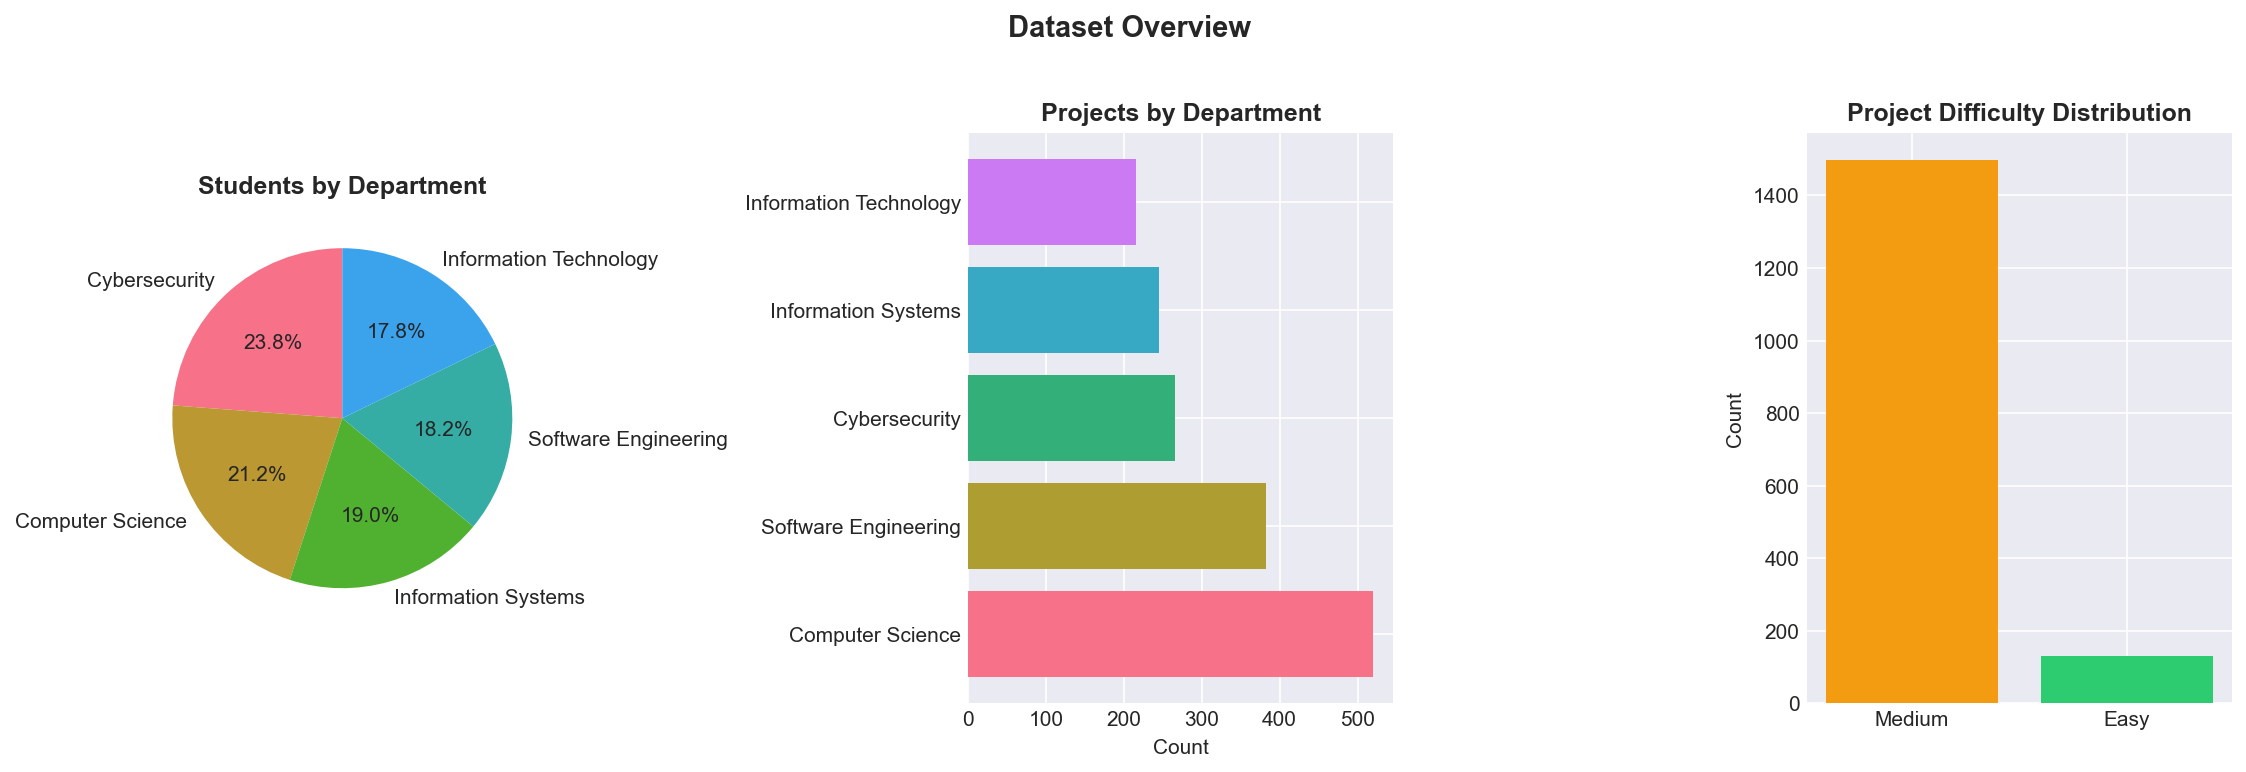

In [111]:
# Plot 1: Dataset Overview
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dept_counts = students['department'].value_counts()
axes[0].pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Students by Department', fontsize=12, fontweight='bold')

proj_dept = projects['department'].value_counts()
axes[1].barh(proj_dept.index, proj_dept.values, color=sns.color_palette("husl", len(proj_dept)))
axes[1].set_title('Projects by Department', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

complexity_counts = projects['difficulty'].value_counts()
colors = {'Easy': '#2ecc71', 'Medium': '#f39c12', 'Hard': '#e74c3c'}
axes[2].bar(complexity_counts.index, complexity_counts.values,
            color=[colors.get(x, '#95a5a6') for x in complexity_counts.index])
axes[2].set_title('Project Difficulty Distribution', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('01_dataset_overview.png')

  Saved: C:\kb\student project\plots2\02_student_demographics.png


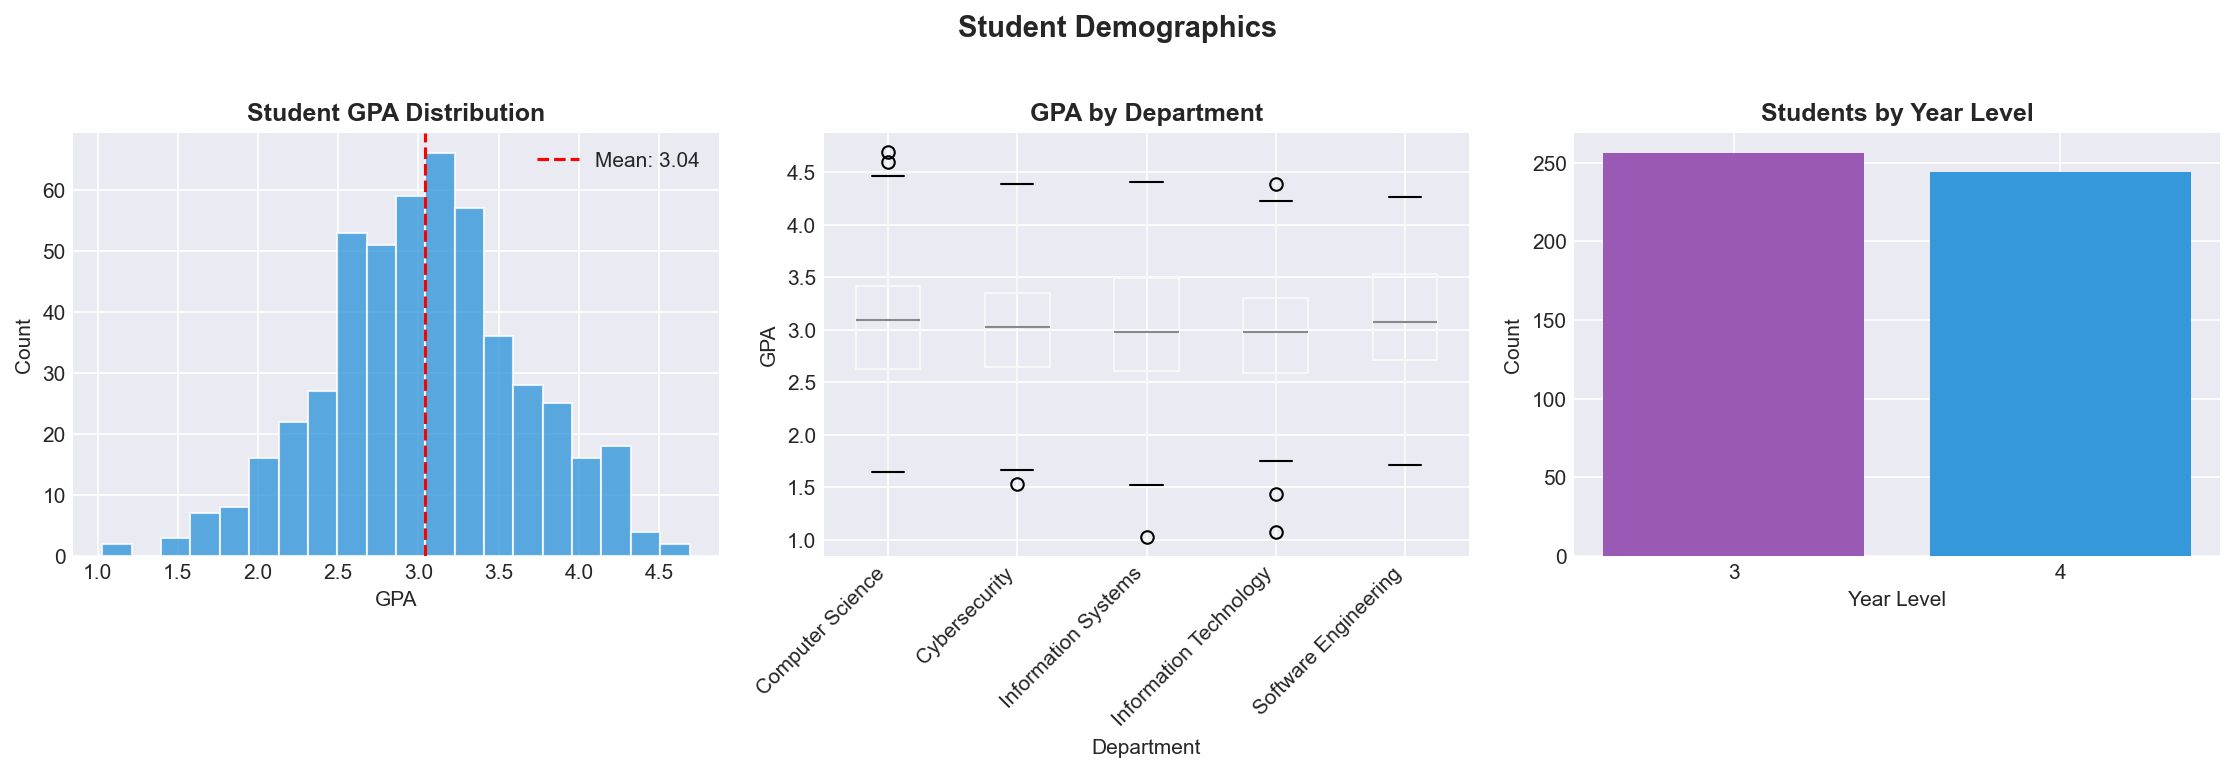

In [112]:
# Plot 2: Student Demographics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(students['gpa'], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(students['gpa'].mean(), color='red', linestyle='--', label=f"Mean: {students['gpa'].mean():.2f}")
axes[0].set_title('Student GPA Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('GPA')
axes[0].set_ylabel('Count')
axes[0].legend()

students.boxplot(column='gpa', by='department', ax=axes[1], rot=45)
axes[1].set_title('GPA by Department', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('GPA')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

year_counts = students['year_level'].value_counts().sort_index()
axes[2].bar(year_counts.index.astype(str), year_counts.values, color=['#9b59b6', '#3498db'])
axes[2].set_title('Students by Year Level', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Year Level')
axes[2].set_ylabel('Count')

plt.suptitle('Student Demographics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('02_student_demographics.png')

  Saved: C:\kb\student project\plots2\03_project_categories.png


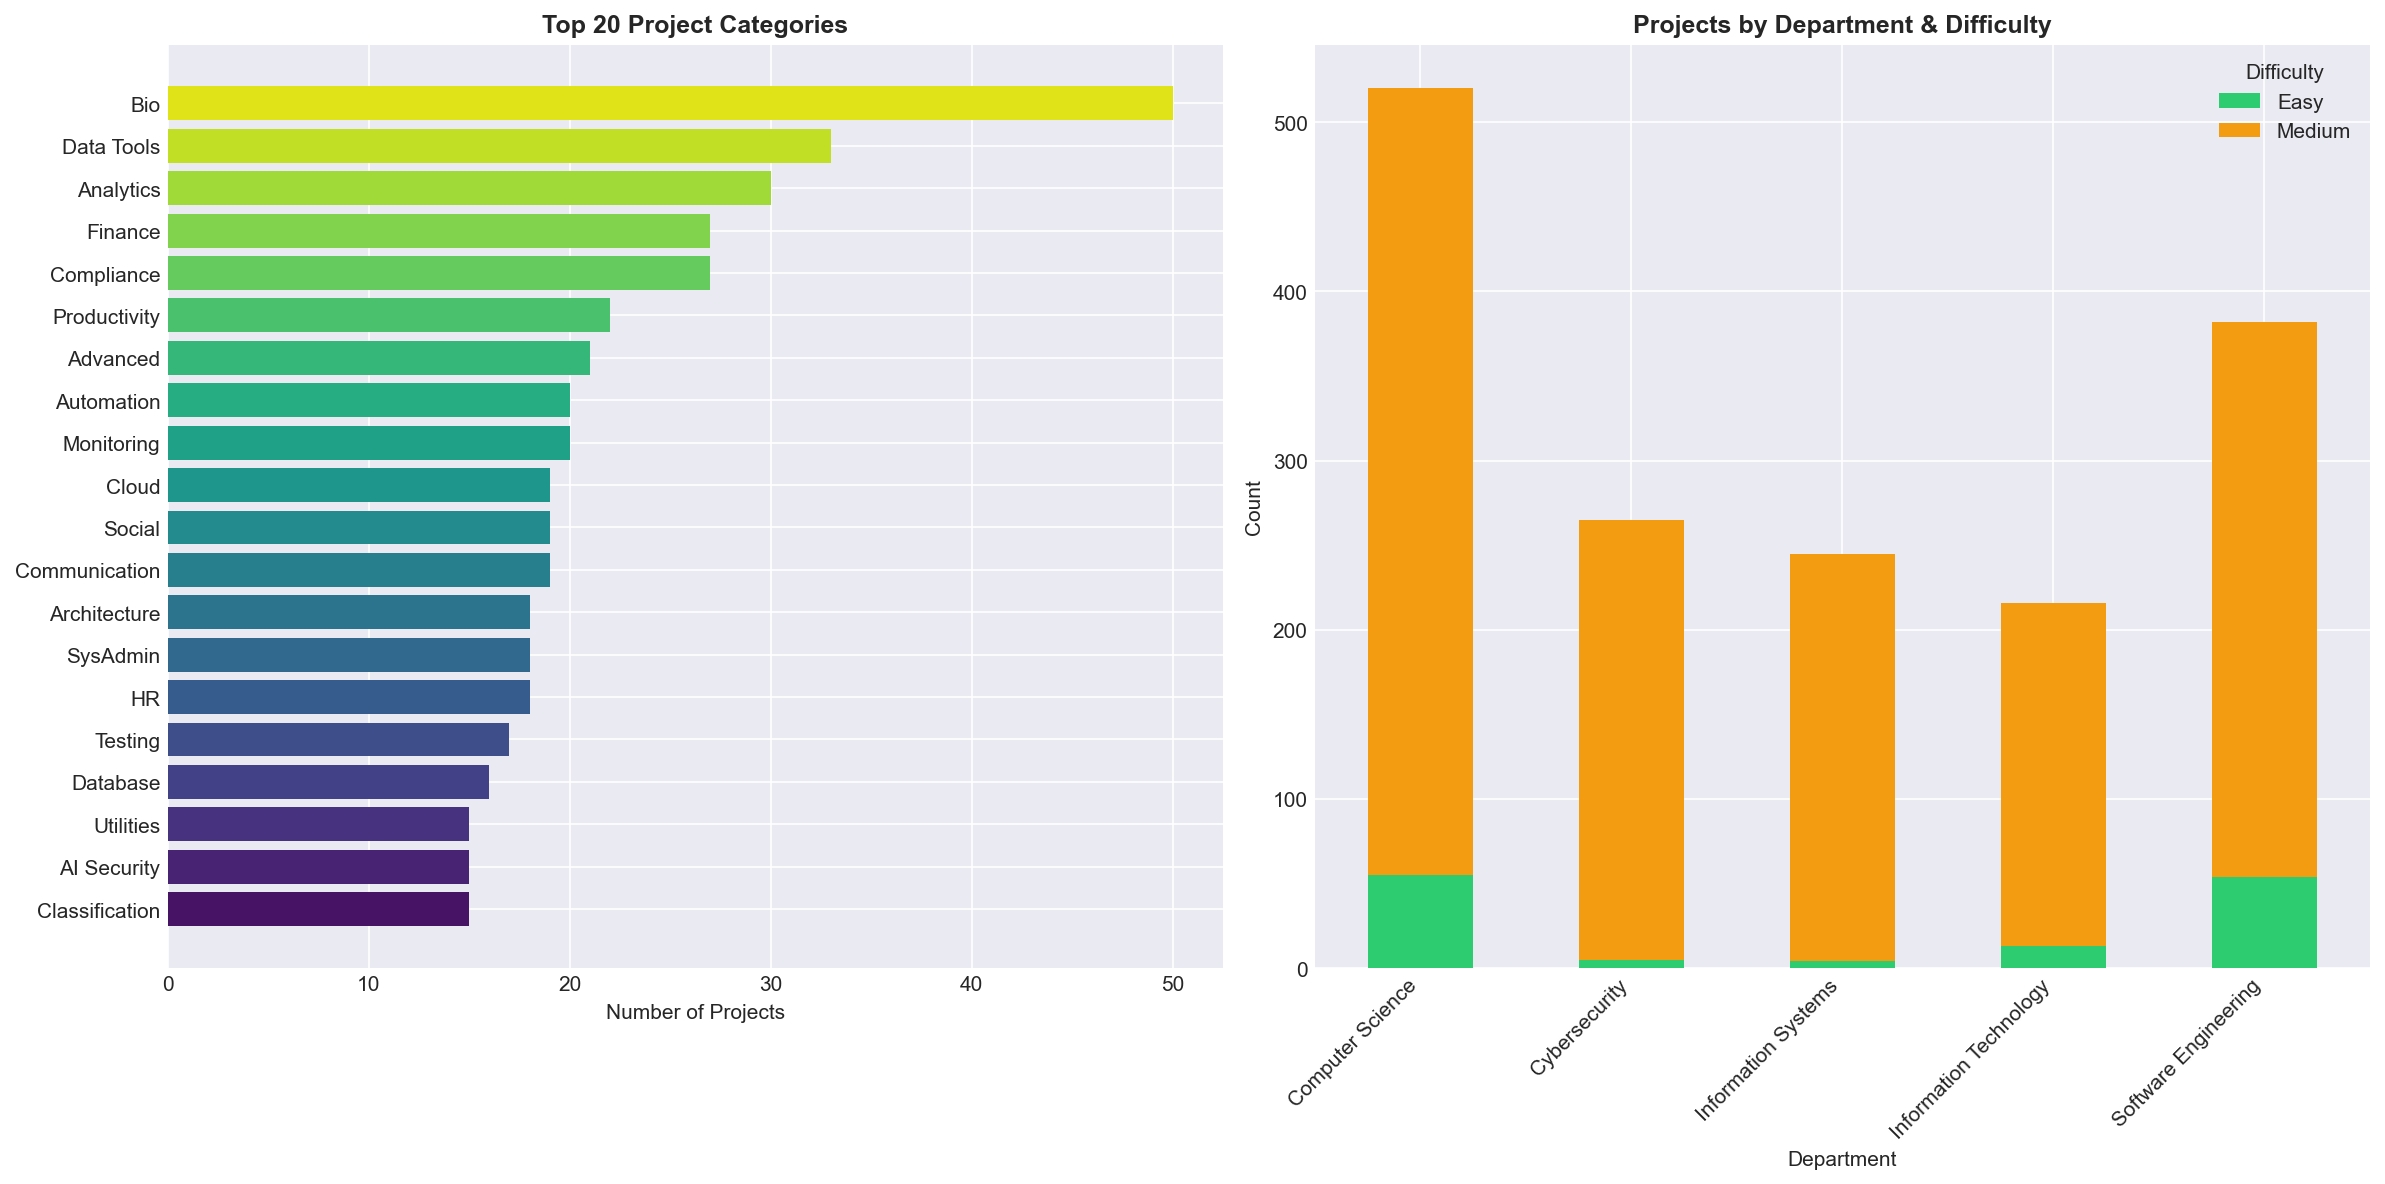

In [113]:
# Plot 3: Project Categories
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

cat_counts = projects['category'].value_counts().head(20)
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color=sns.color_palette("viridis", 20))
axes[0].set_title('Top 20 Project Categories', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Projects')

dept_diff = pd.crosstab(projects['department'], projects['difficulty'])
dept_diff.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Projects by Department & Difficulty', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Count')
axes[1].legend(title='Difficulty')
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
save_plot('03_project_categories.png')

  Saved: C:\kb\student project\plots2\04_wordclouds.png


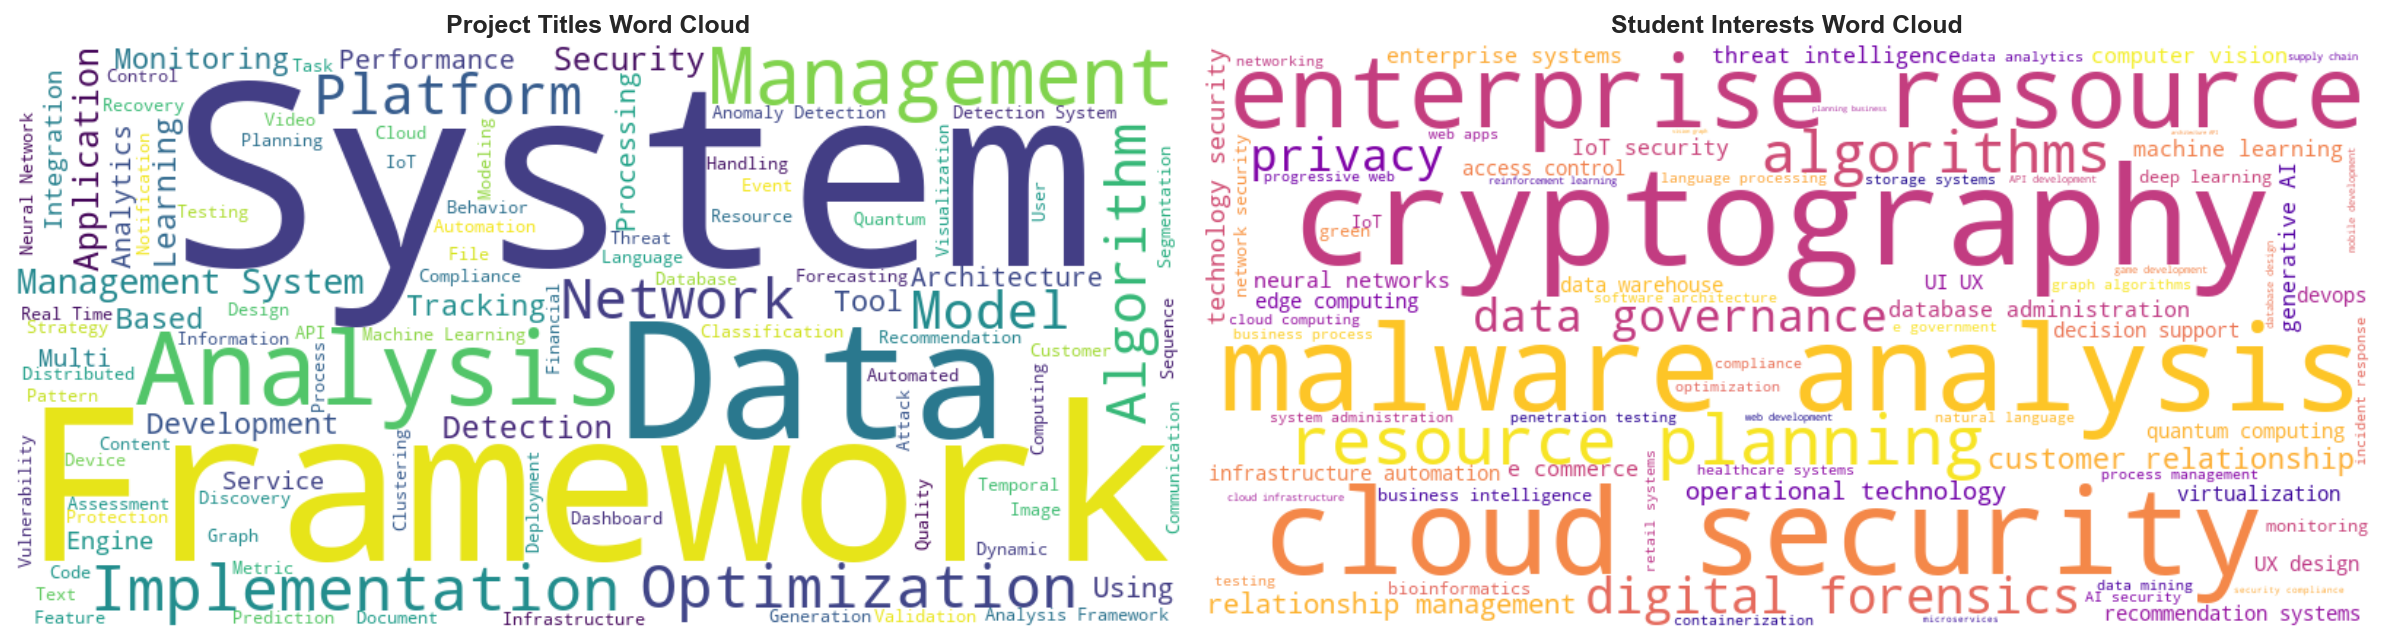

In [114]:
# Plot 4: Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_titles = ' '.join(projects['title'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(all_titles)
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Project Titles Word Cloud', fontsize=12, fontweight='bold')

all_interests = ' '.join(students['interests'].tolist())
wordcloud2 = WordCloud(width=800, height=400, background_color='white',
                       colormap='plasma', max_words=100).generate(all_interests)
axes[1].imshow(wordcloud2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Student Interests Word Cloud', fontsize=12, fontweight='bold')

plt.tight_layout()
save_plot('04_wordclouds.png')

  Saved: C:\kb\student project\plots2\05_history_analysis.png


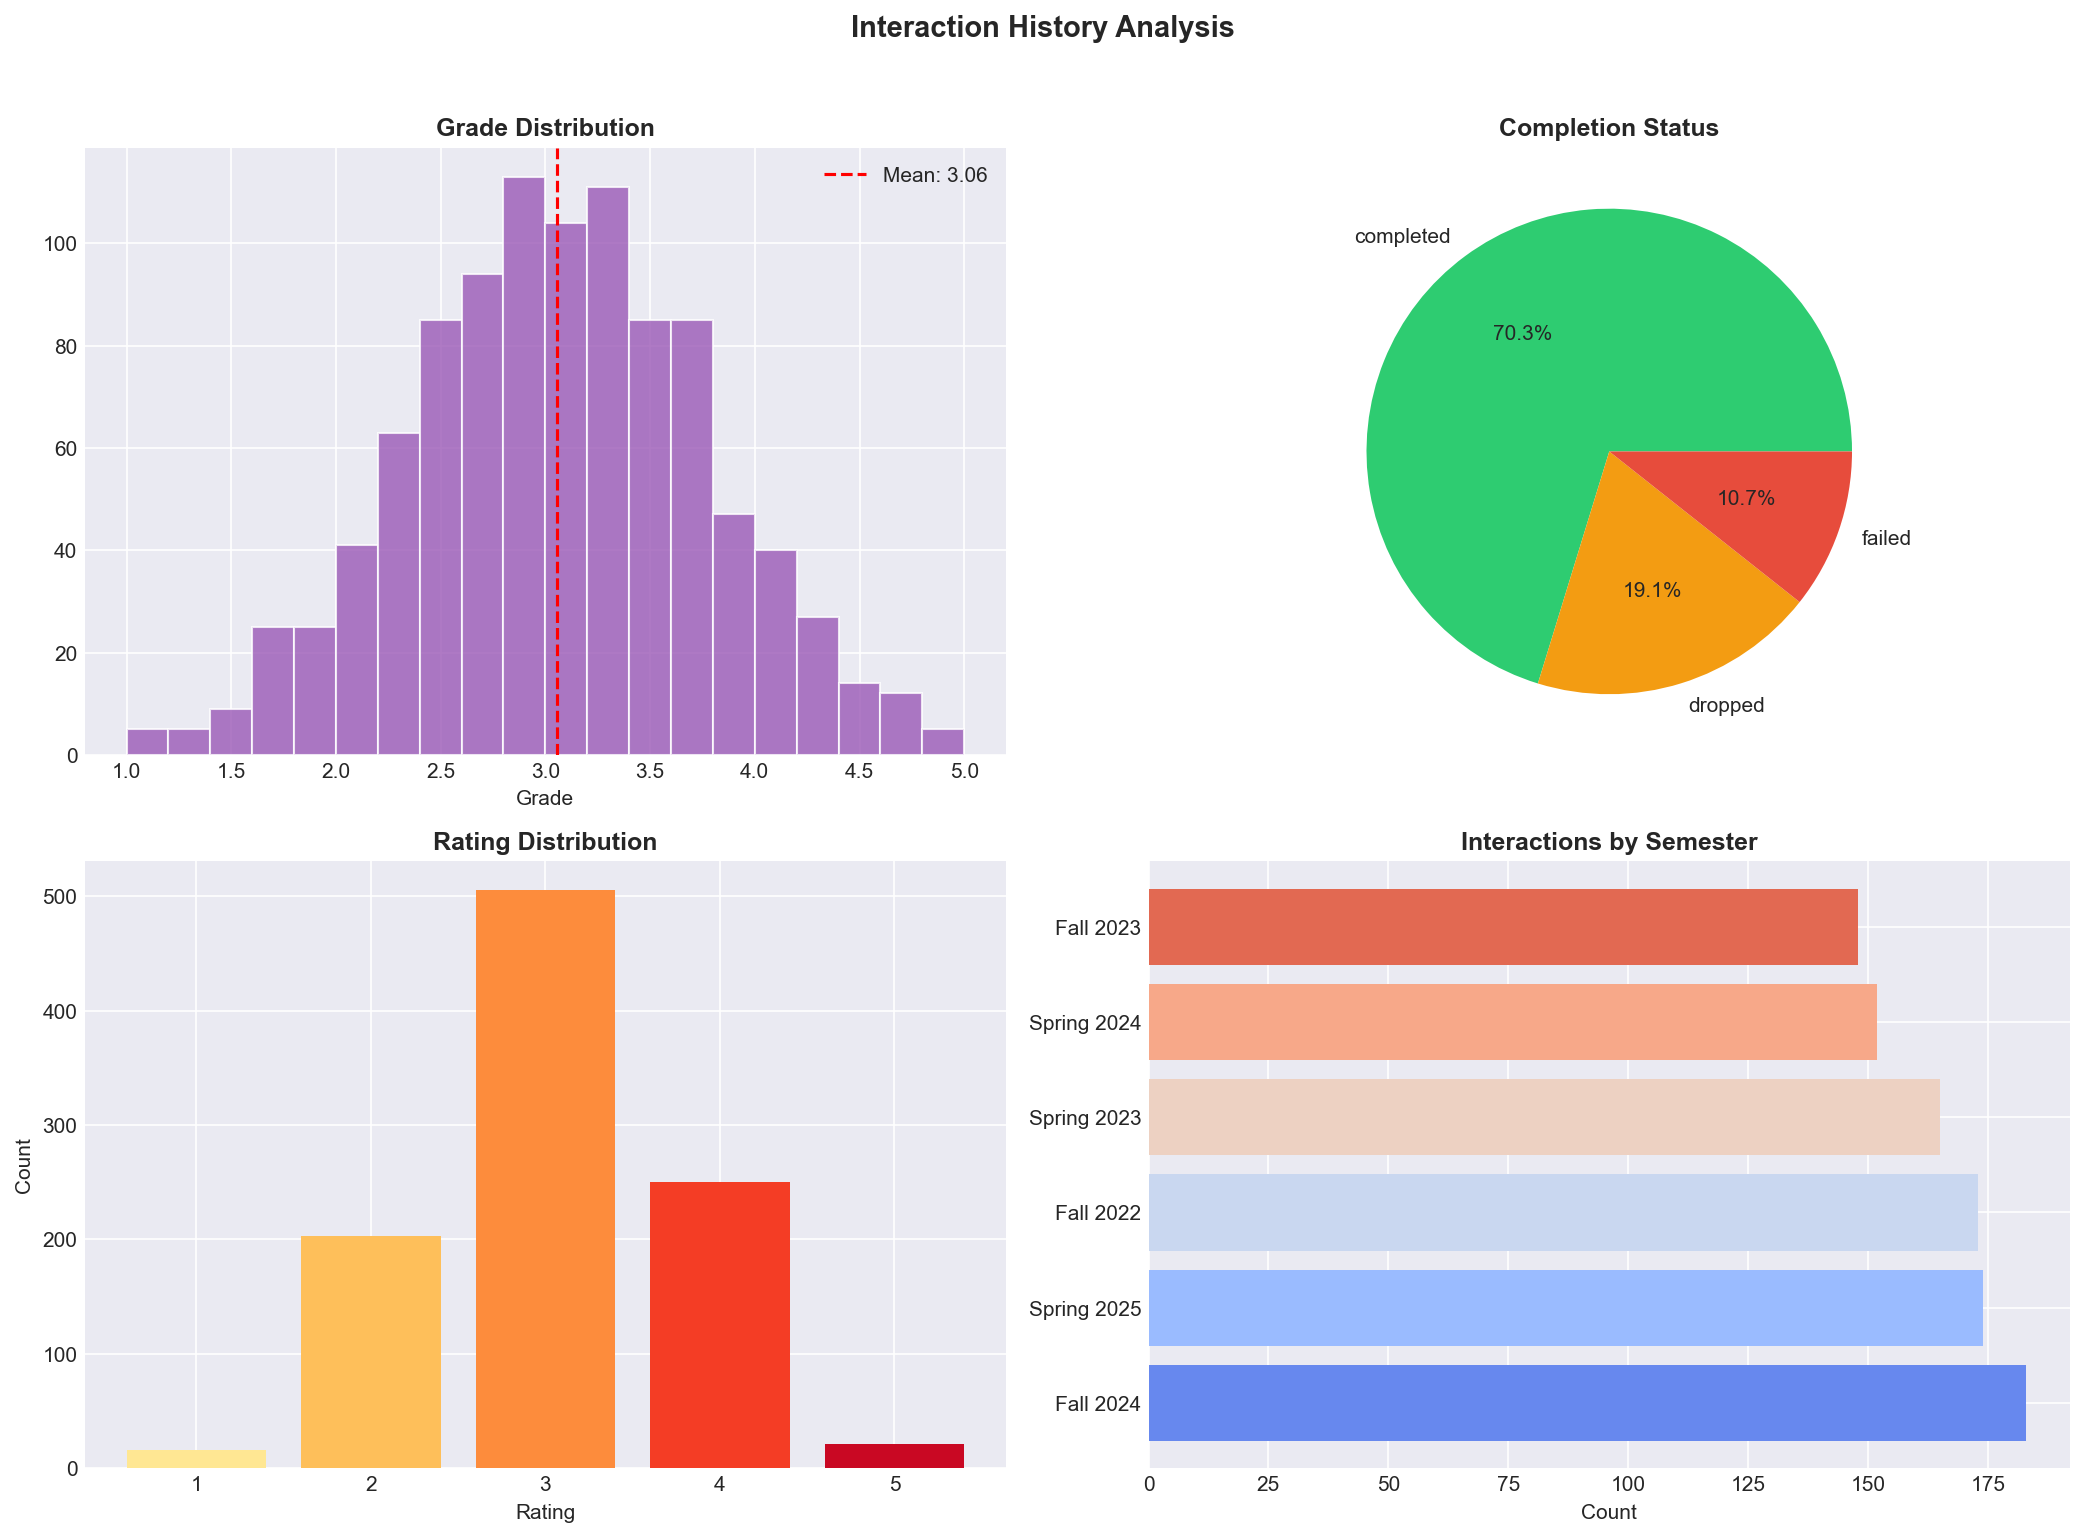

In [115]:
# Plot 5: History Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(history['grade'], bins=20, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(history['grade'].mean(), color='red', linestyle='--',
                    label=f"Mean: {history['grade'].mean():.2f}")
axes[0, 0].set_title('Grade Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Grade')
axes[0, 0].legend()

status_counts = history['completion_status'].value_counts()
colors_status = {'completed': '#2ecc71', 'dropped': '#f39c12', 'failed': '#e74c3c'}
axes[0, 1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
               colors=[colors_status.get(x, '#95a5a6') for x in status_counts.index])
axes[0, 1].set_title('Completion Status', fontsize=12, fontweight='bold')

rating_counts = history['rating'].value_counts().sort_index()
axes[1, 0].bar(rating_counts.index, rating_counts.values, color=sns.color_palette("YlOrRd", 5))
axes[1, 0].set_title('Rating Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Count')

sem_counts = history['semester'].value_counts()
axes[1, 1].barh(sem_counts.index, sem_counts.values, color=sns.color_palette("coolwarm", len(sem_counts)))
axes[1, 1].set_title('Interactions by Semester', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')

plt.suptitle('Interaction History Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('05_history_analysis.png')

  Saved: C:\kb\student project\plots2\06_skills_distribution.png


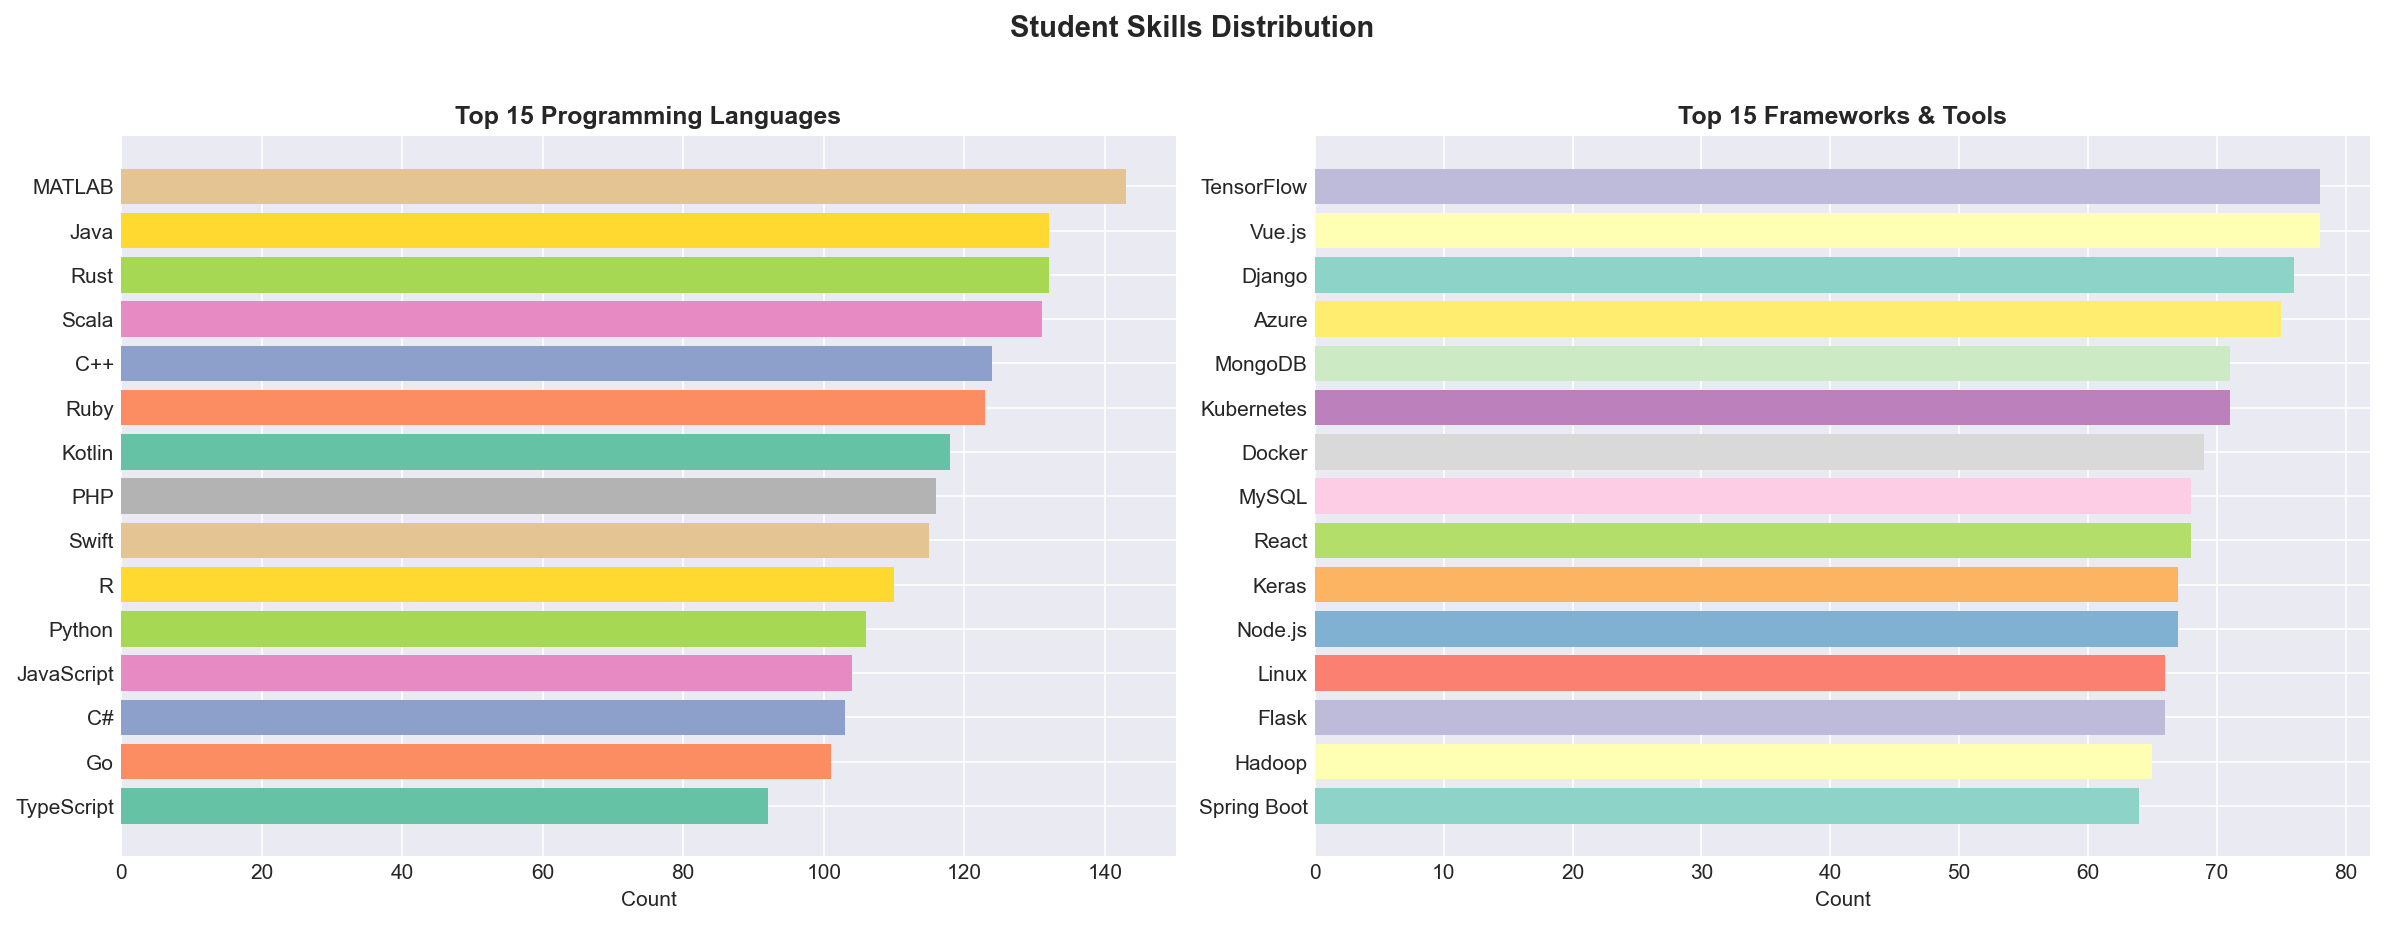

In [116]:
# Plot 6: Skills Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

all_langs = []
for langs in students['programming_languages'].str.split(', '):
    all_langs.extend(langs)
lang_counts = pd.Series(all_langs).value_counts().head(15)
axes[0].barh(lang_counts.index[::-1], lang_counts.values[::-1], color=sns.color_palette("Set2", 15))
axes[0].set_title('Top 15 Programming Languages', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')

all_tools = []
for tools in students['frameworks_tools'].str.split(', '):
    all_tools.extend(tools)
tool_counts = pd.Series(all_tools).value_counts().head(15)
axes[1].barh(tool_counts.index[::-1], tool_counts.values[::-1], color=sns.color_palette("Set3", 15))
axes[1].set_title('Top 15 Frameworks & Tools', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Student Skills Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('06_skills_distribution.png')

## 3. Feature Engineering

In [117]:
dept_encoder = LabelEncoder()
cat_encoder = LabelEncoder()
scaler = MinMaxScaler()

# Student features
students['dept_encoded'] = dept_encoder.fit_transform(students['department'])
diff_map = {'Easy': 0, 'Medium': 1, 'Hard': 2}
students['pref_diff_encoded'] = students['preferred_difficulty'].map(diff_map)
students['gpa_norm'] = scaler.fit_transform(students[['gpa']])
students['avg_cs_grade_norm'] = scaler.fit_transform(students[['avg_cs_grade']])
students['prog_langs_list'] = students['programming_languages'].str.split(', ')
students['fw_tools_list'] = students['frameworks_tools'].str.split(', ')

# Project features
projects['dept_encoded'] = dept_encoder.transform(projects['department'])
projects['diff_encoded'] = projects['difficulty'].map(diff_map)
projects['cat_encoded'] = cat_encoder.fit_transform(projects['category'])
projects['avg_grade_norm'] = scaler.fit_transform(projects[['avg_grade_given']])
projects['times_selected_norm'] = scaler.fit_transform(projects[['times_selected']])
projects['skills_list'] = projects['required_skills'].str.split(', ')
projects['tech_list'] = projects['tech_stack'].str.split(', ')

print(f"Student features: {students.shape[1]} columns")
print(f"Project features: {projects.shape[1]} columns")

Student features: 18 columns
Project features: 17 columns


In [118]:
# TF-IDF Vectorization
interest_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
interest_tfidf = interest_vectorizer.fit_transform(students['interests'])

projects['text_content'] = projects['title'] + ' ' + projects['description']
project_vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
project_tfidf = project_vectorizer.fit_transform(projects['text_content'])

print(f"Interest TF-IDF: {interest_tfidf.shape}")
print(f"Project TF-IDF: {project_tfidf.shape}")

Interest TF-IDF: (500, 88)
Project TF-IDF: (1628, 200)


  Saved: C:\kb\student project\plots2\07_feature_correlations.png


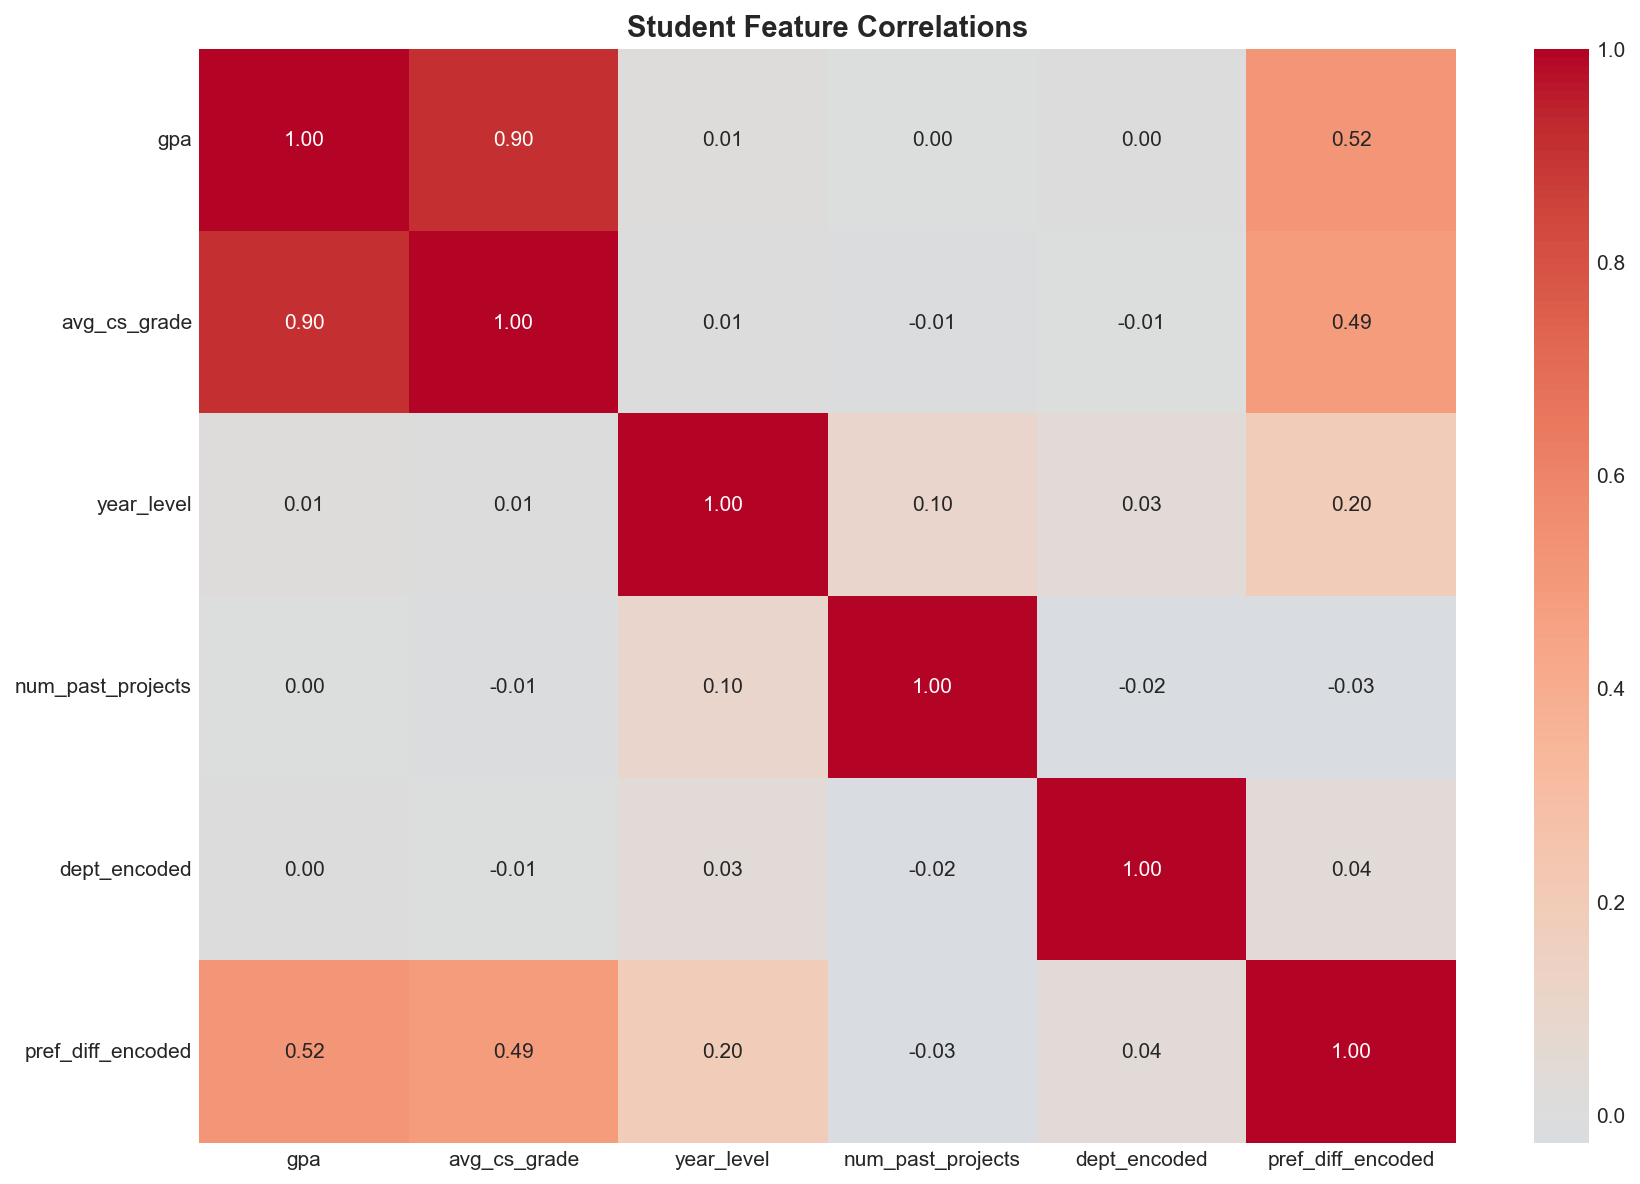

In [119]:
# Plot 7: Feature Correlations
fig, ax = plt.subplots(figsize=(12, 8))

numerical_features = students[['gpa', 'avg_cs_grade', 'year_level', 'num_past_projects']].copy()
numerical_features['dept_encoded'] = students['dept_encoded']
numerical_features['pref_diff_encoded'] = students['pref_diff_encoded']

corr_matrix = numerical_features.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.2f')
ax.set_title('Student Feature Correlations', fontsize=14, fontweight='bold')

plt.tight_layout()
save_plot('07_feature_correlations.png')

## 4. Content-Based Component

In [120]:
def calculate_skill_match(student_skills, project_skills):
    student_set = set([s.lower().strip() for s in student_skills])
    project_set = set([s.lower().strip() for s in project_skills])
    if not student_set or not project_set:
        return 0.0
    intersection = student_set.intersection(project_set)
    union = student_set.union(project_set)
    return len(intersection) / len(union) if union else 0.0

# Calculate content scores for student 0
student = students.iloc[0]
student_skills = student['prog_langs_list'] + student['fw_tools_list']
student_text = student['interests'] + ' ' + ' '.join(student_skills)
student_vec = project_vectorizer.transform([student_text])
content_scores = cosine_similarity(student_vec, project_tfidf).flatten()

print(f"Content scores range: [{content_scores.min():.4f}, {content_scores.max():.4f}]")

Content scores range: [0.0000, 0.7360]


  Saved: C:\kb\student project\plots2\08_content_based_scores.png


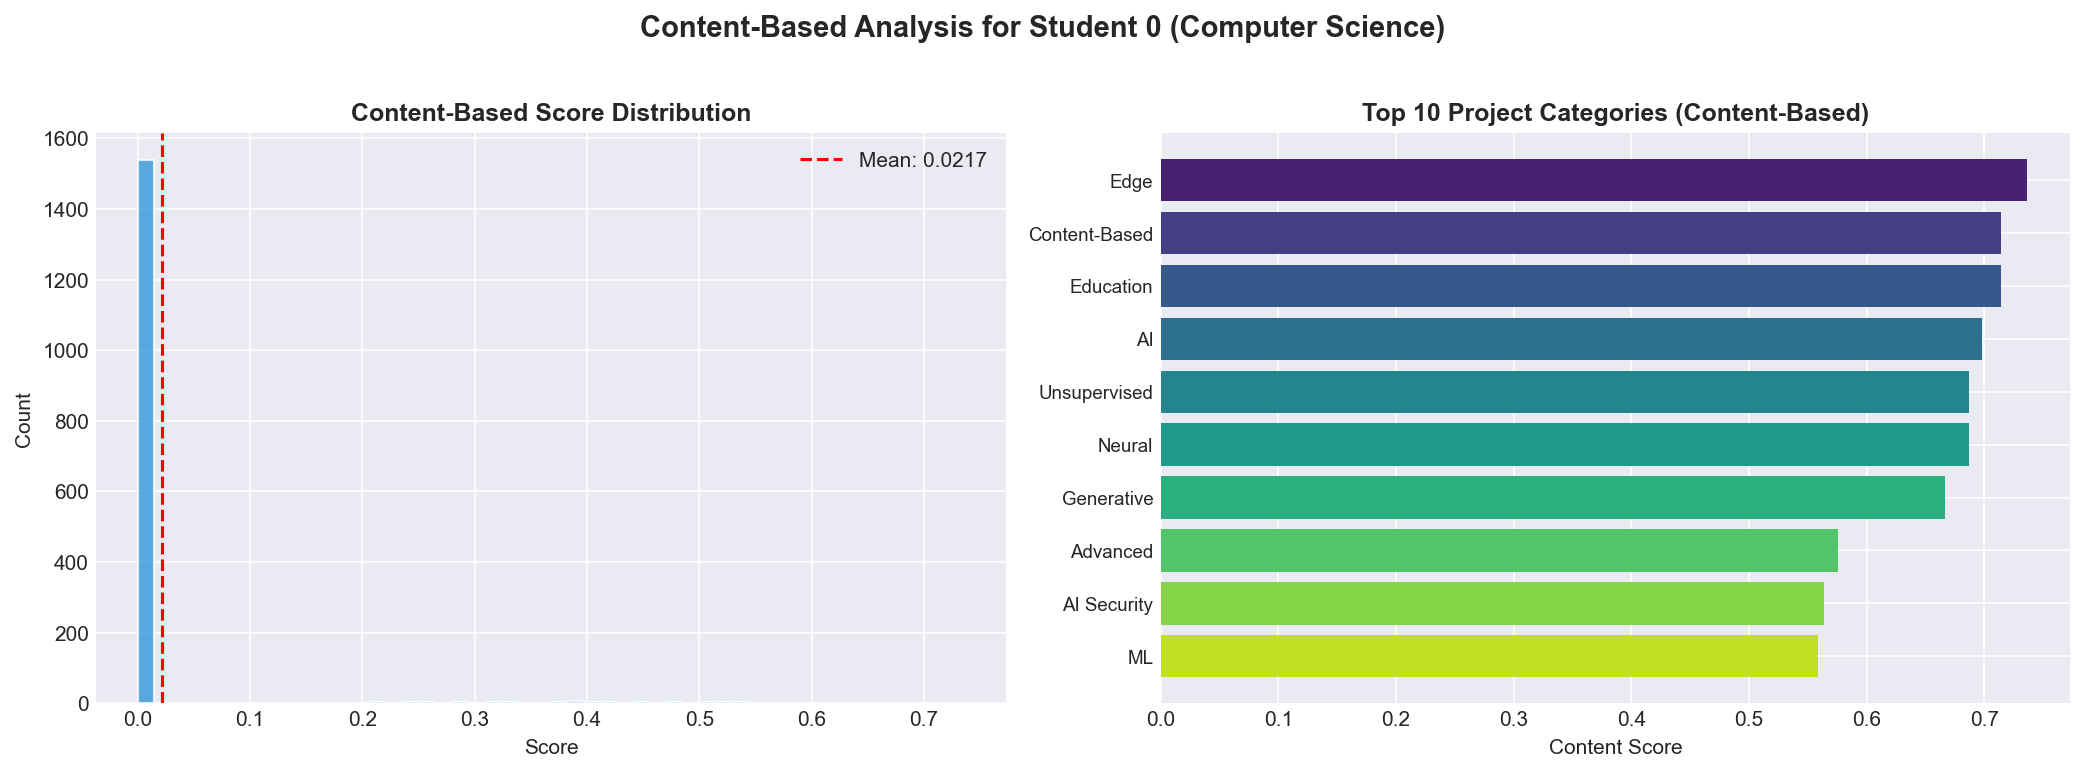

In [121]:
# Plot 8: Content-Based Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(content_scores, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(content_scores.mean(), color='red', linestyle='--',
                label=f'Mean: {content_scores.mean():.4f}')
axes[0].set_title('Content-Based Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

top_indices = np.argsort(content_scores)[-10:][::-1]
top_scores = content_scores[top_indices]
top_categories = [projects.iloc[i]['category'] for i in top_indices]
colors = sns.color_palette("viridis", 10)
axes[1].barh(range(10), top_scores, color=colors)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top_categories, fontsize=9)
axes[1].set_title('Top 10 Project Categories (Content-Based)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Content Score')
axes[1].invert_yaxis()

plt.suptitle(f'Content-Based Analysis for Student 0 ({students.iloc[0]["department"]})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('08_content_based_scores.png')

## 5. Collaborative Filtering Component

Interaction matrix: (500, 1628)
Non-zero: 995
Sparsity: 99.8778%
  Saved: C:\kb\student project\plots2\09_collaborative_matrix.png


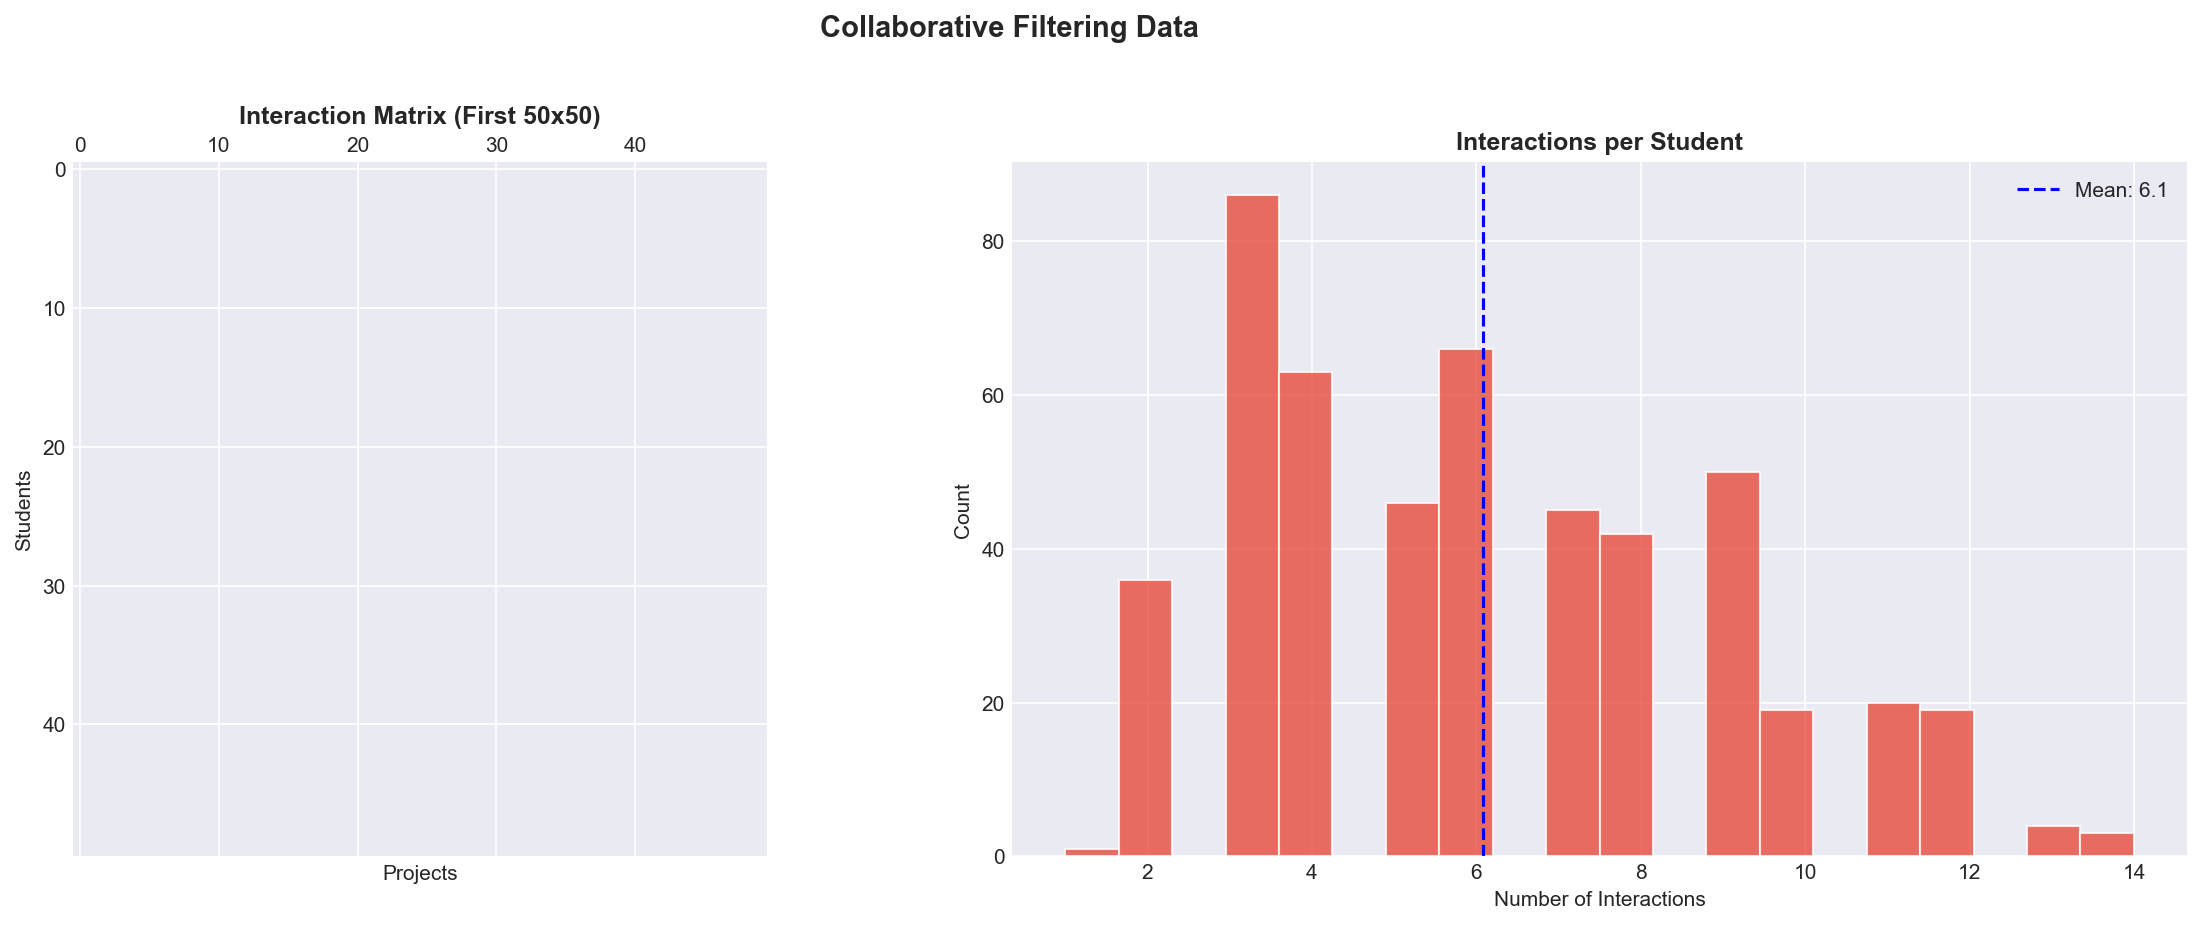

In [122]:
# Build interaction matrix
student_id_to_idx = {sid: i for i, sid in enumerate(students['student_id'])}
project_id_to_idx = {pid: i for i, pid in enumerate(projects['project_id'])}

n_students = len(students)
n_projects = len(projects)

rows, cols, vals = [], [], []
for _, row in history.iterrows():
    if row['student_id'] in student_id_to_idx and row['project_id'] in project_id_to_idx:
        rows.append(student_id_to_idx[row['student_id']])
        cols.append(project_id_to_idx[row['project_id']])
        vals.append(row['rating'])

interaction_matrix = csr_matrix((vals, (rows, cols)), shape=(n_students, n_projects))
print(f"Interaction matrix: {interaction_matrix.shape}")
print(f"Non-zero: {interaction_matrix.nnz}")
print(f"Sparsity: {1 - interaction_matrix.nnz / (n_students * n_projects):.4%}")

# Plot 9: Interaction Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample_size = 50
sample_matrix = interaction_matrix[:sample_size, :sample_size].toarray()
axes[0].spy(sample_matrix, markersize=2, color='#3498db')
axes[0].set_title(f'Interaction Matrix (First {sample_size}x{sample_size})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Projects')
axes[0].set_ylabel('Students')

interactions_per_student = np.array(interaction_matrix.sum(axis=1)).flatten()
axes[1].hist(interactions_per_student, bins=20, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].axvline(interactions_per_student.mean(), color='blue', linestyle='--',
                label=f'Mean: {interactions_per_student.mean():.1f}')
axes[1].set_title('Interactions per Student', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Interactions')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Collaborative Filtering Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('09_collaborative_matrix.png')

In [123]:
# Apply SVD
n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
student_factors = svd.fit_transform(interaction_matrix)
project_factors = svd.components_.T

print(f"Student factors: {student_factors.shape}")
print(f"Project factors: {project_factors.shape}")
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.4f}")

Student factors: (500, 50)
Project factors: (1628, 50)
Explained variance: 0.2887


  Saved: C:\kb\student project\plots2\10_svd_analysis.png


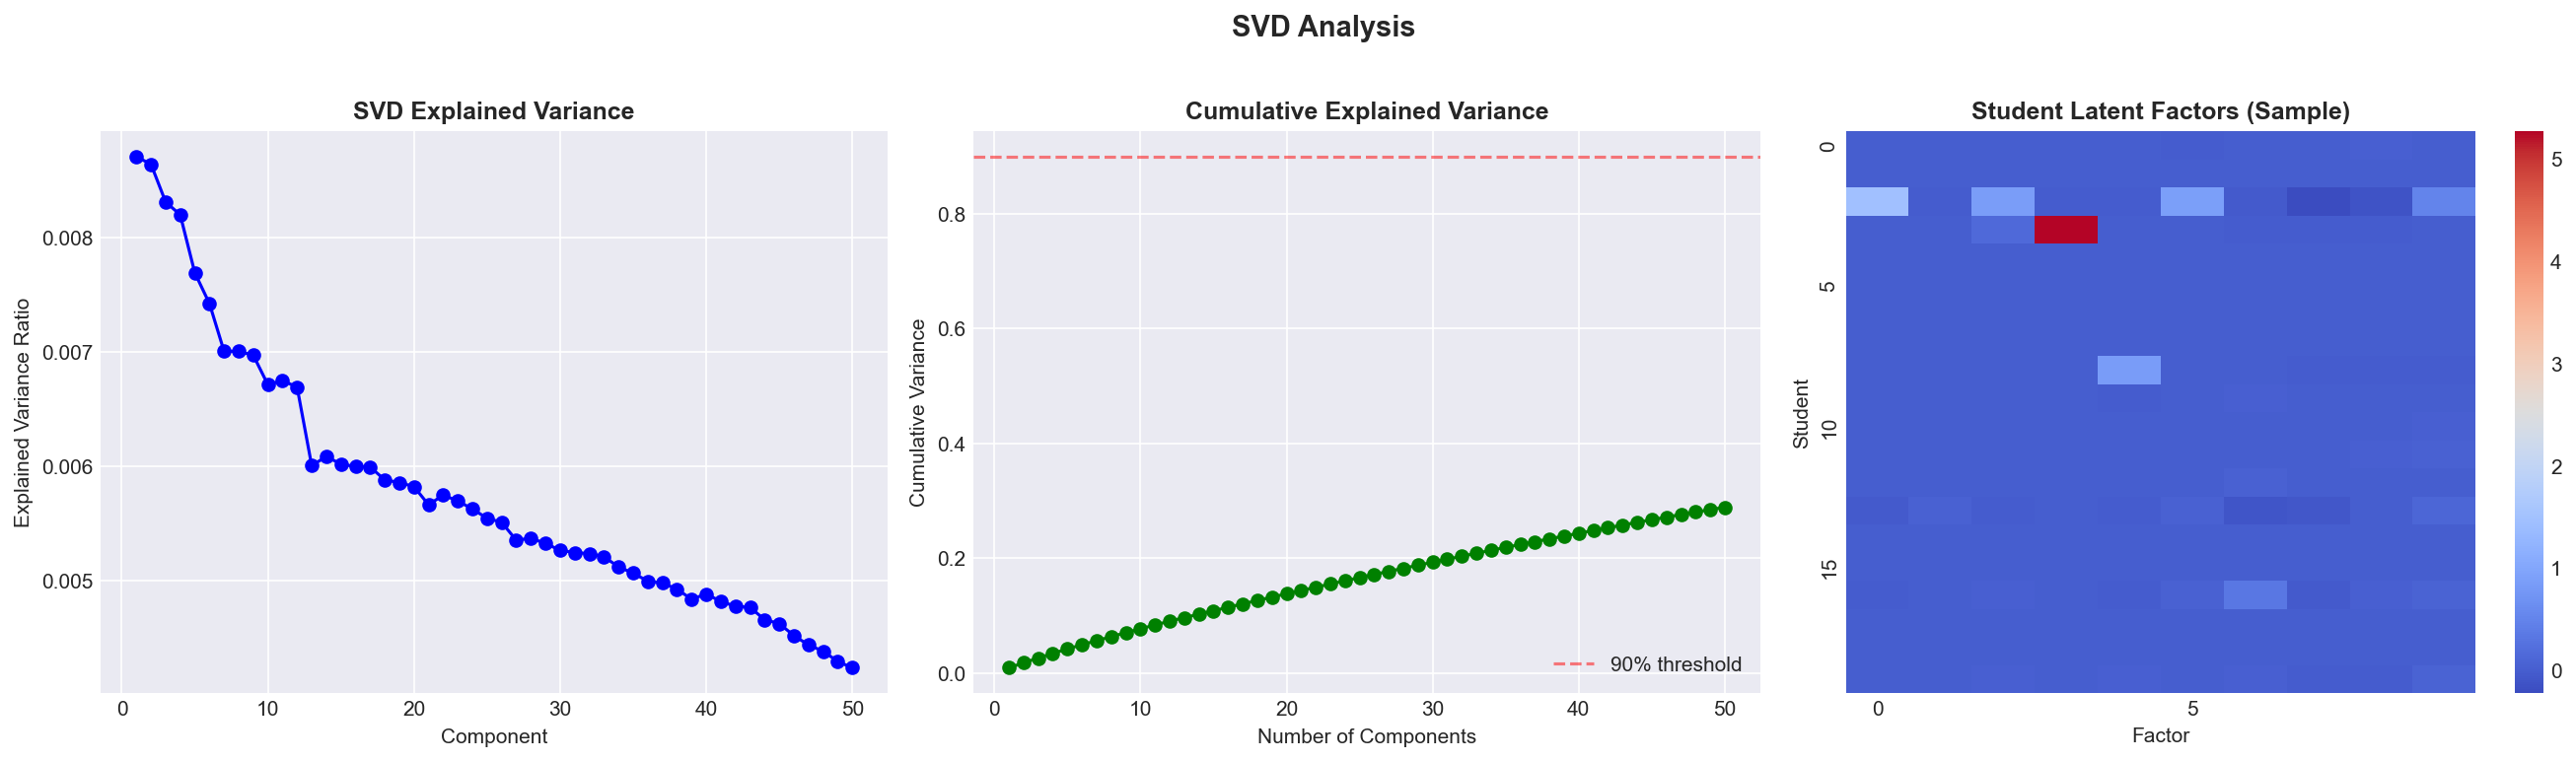

In [124]:
# Plot 10: SVD Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, n_components + 1), svd.explained_variance_ratio_, 'bo-')
axes[0].set_title('SVD Explained Variance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')

cumvar = np.cumsum(svd.explained_variance_ratio_)
axes[1].plot(range(1, n_components + 1), cumvar, 'go-')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='90% threshold')
axes[1].legend()

sample_factors = student_factors[:20, :10]
sns.heatmap(sample_factors, cmap='coolwarm', ax=axes[2], xticklabels=5, yticklabels=5)
axes[2].set_title('Student Latent Factors (Sample)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Factor')
axes[2].set_ylabel('Student')

plt.suptitle('SVD Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('10_svd_analysis.png')

In [125]:
# Collaborative scores for student 0
student_vec = student_factors[0]
collab_scores = np.dot(project_factors, student_vec)
collab_scores = (collab_scores - collab_scores.min()) / (collab_scores.max() - collab_scores.min() + 1e-8)
print(f"Collaborative scores range: [{collab_scores.min():.4f}, {collab_scores.max():.4f}]")

Collaborative scores range: [0.0000, 1.0000]


  Saved: C:\kb\student project\plots2\11_content_vs_collab.png


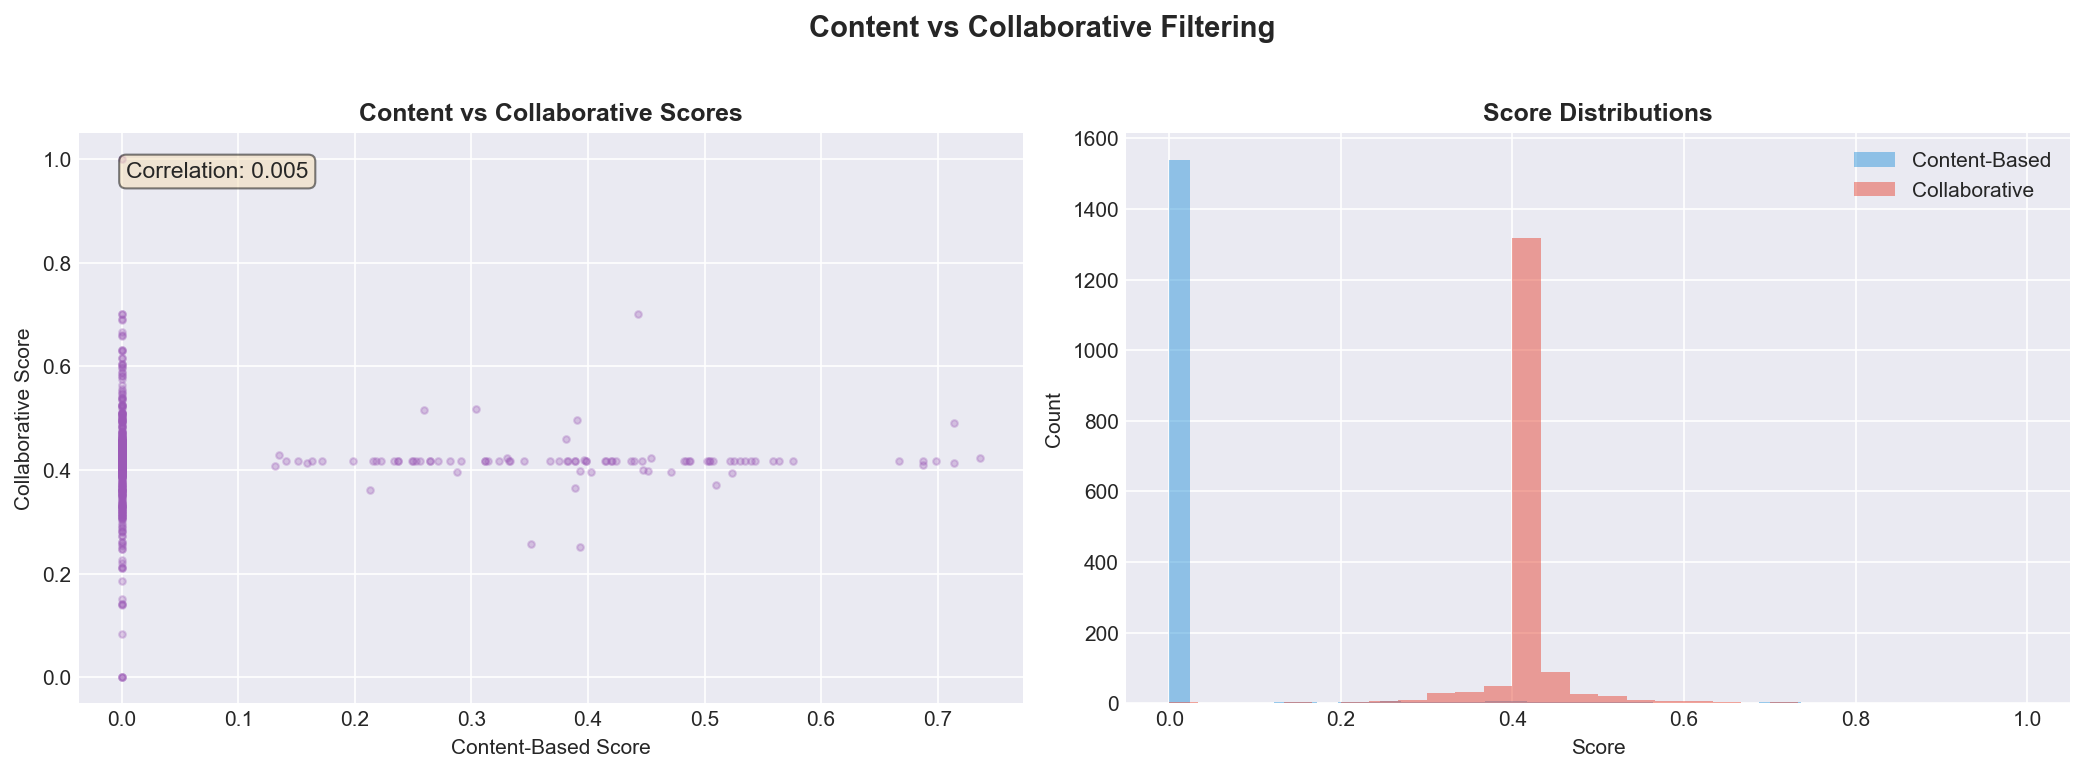

In [126]:
# Plot 11: Content vs Collaborative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(content_scores, collab_scores, alpha=0.3, s=10, color='#9b59b6')
axes[0].set_xlabel('Content-Based Score')
axes[0].set_ylabel('Collaborative Score')
axes[0].set_title('Content vs Collaborative Scores', fontsize=12, fontweight='bold')
corr = np.corrcoef(content_scores, collab_scores)[0, 1]
axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].hist(content_scores, bins=30, alpha=0.5, label='Content-Based', color='#3498db')
axes[1].hist(collab_scores, bins=30, alpha=0.5, label='Collaborative', color='#e74c3c')
axes[1].set_title('Score Distributions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Content vs Collaborative Filtering', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('11_content_vs_collab.png')

## 6. Training Data Generation

In [127]:
# Generate positive and negative pairs
positive_pairs = []
# Map relevance to integer degrees (required by XGBoost ranker)
def map_relevance(grade, status):
    # grade assumed on 0-100 scale; map to 0-5 integer relevance
    rel = int(np.clip(round(grade / 20), 0, 5))
    # ensure completed interactions have at least relevance 1
    if status == 1 and rel == 0:
        rel = 1
    return int(rel)

for _, row in history.iterrows():
    if row['student_id'] in student_id_to_idx and row['project_id'] in project_id_to_idx:
        s_idx = student_id_to_idx[row['student_id']]
        p_idx = project_id_to_idx[row['project_id']]
        grade = row.get('grade', 0)
        status = 1 if row.get('completion_status') == 'completed' else 0
        relevance = map_relevance(grade, status)
        positive_pairs.append((s_idx, p_idx, relevance))

# Negative samples remain relevance 0
negative_pairs = []
np.random.seed(42)
for s_idx, p_idx, _ in positive_pairs:
    for _ in range(3):
        neg_p_idx = np.random.randint(0, n_projects)
        negative_pairs.append((s_idx, neg_p_idx, 0))

all_pairs = positive_pairs + negative_pairs
print(f"Positive: {len(positive_pairs)}, Negative: {len(negative_pairs)}, Total: {len(all_pairs)}")

Positive: 995, Negative: 2985, Total: 3980


  Saved: C:\kb\student project\plots2\12_training_data.png


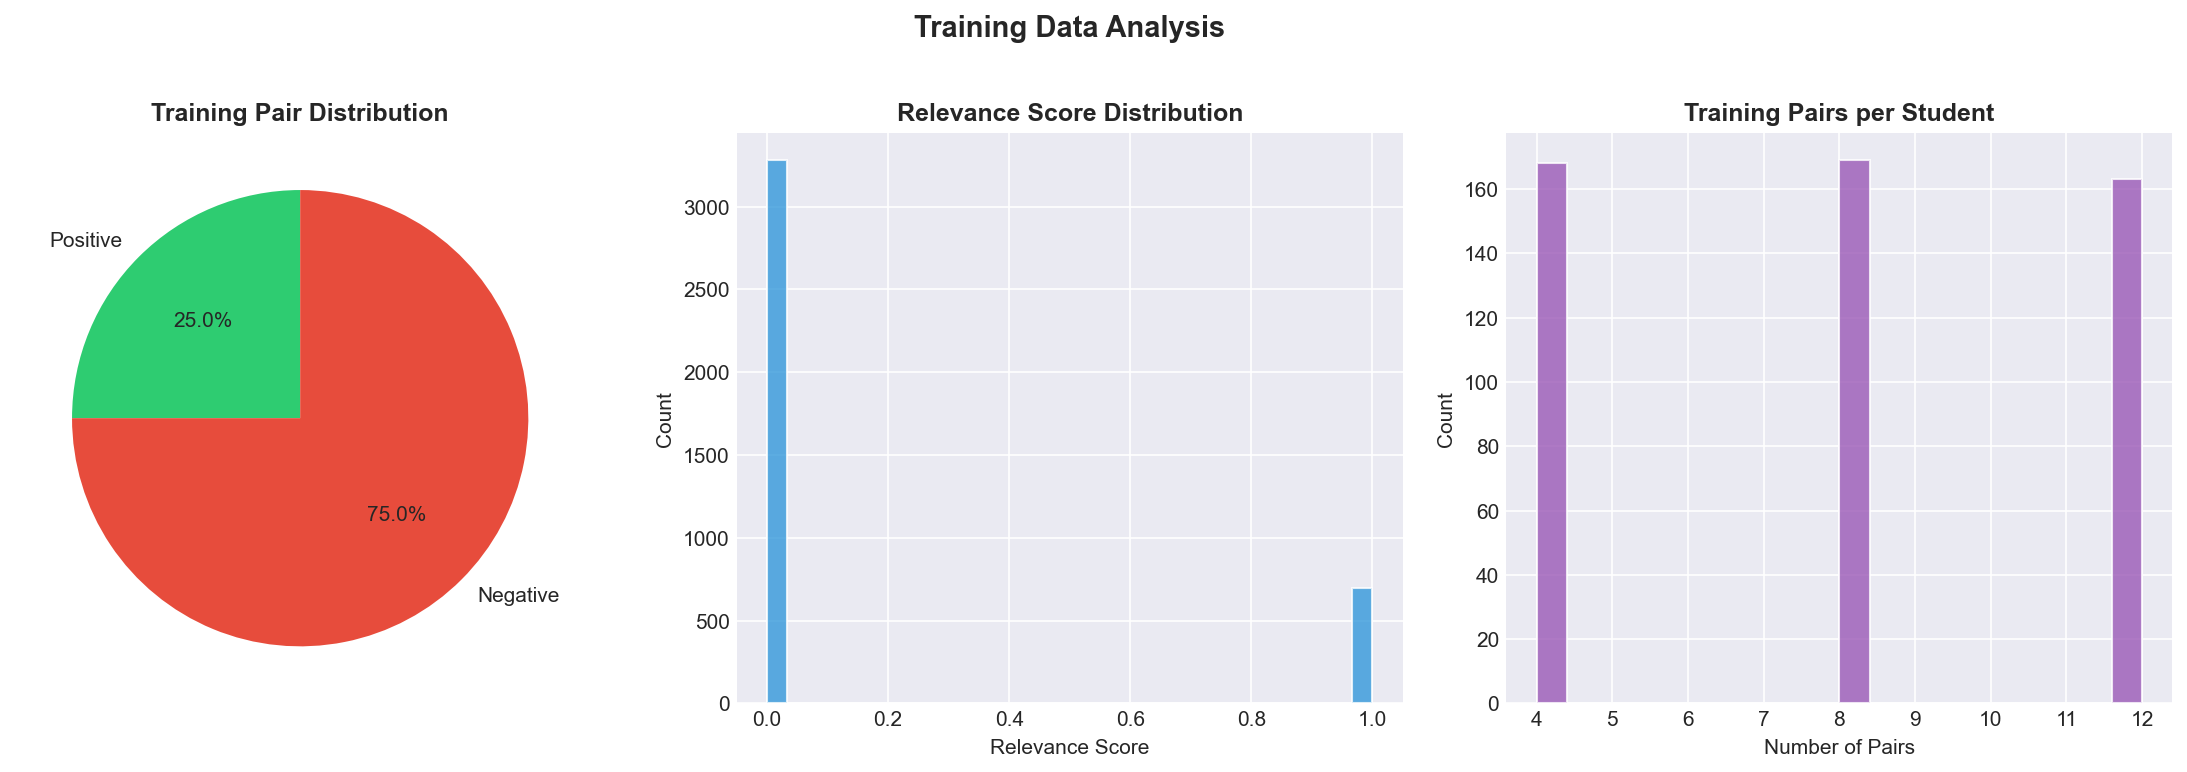

In [128]:
# Plot 12: Training Data
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pair_types = ['Positive', 'Negative']
pair_counts = [len(positive_pairs), len(negative_pairs)]
axes[0].pie(pair_counts, labels=pair_types, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Training Pair Distribution', fontsize=12, fontweight='bold')

relevance_scores = [p[2] for p in all_pairs]
axes[1].hist(relevance_scores, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_title('Relevance Score Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Relevance Score')
axes[1].set_ylabel('Count')

pairs_per_student = defaultdict(int)
for s_idx, _, _ in all_pairs:
    pairs_per_student[s_idx] += 1
pairs_counts = list(pairs_per_student.values())
axes[2].hist(pairs_counts, bins=20, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[2].set_title('Training Pairs per Student', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Pairs')
axes[2].set_ylabel('Count')

plt.suptitle('Training Data Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('12_training_data.png')

## 7. Feature Extraction

In [129]:
# Pre-compute matrices
student_features_df = students[['dept_encoded', 'year_level', 'gpa_norm',
                                 'avg_cs_grade_norm', 'pref_diff_encoded', 'num_past_projects']].values
project_features_df = projects[['dept_encoded', 'diff_encoded', 'cat_encoded',
                                 'avg_grade_norm', 'times_selected_norm']].values

dept_match_matrix = (students['department'].values[:, None] == projects['department'].values[None, :]).astype(float)
diff_match_matrix = 1.0 - np.abs(students['pref_diff_encoded'].values[:, None] -
                                  projects['diff_encoded'].values[None, :]) / 2.0

# Content scores for all students
content_scores_all = np.zeros((n_students, n_projects))
for i in range(n_students):
    student = students.iloc[i]
    student_skills = student['prog_langs_list'] + student['fw_tools_list']
    student_text = student['interests'] + ' ' + ' '.join(student_skills)
    student_vec = project_vectorizer.transform([student_text])
    content_scores_all[i] = cosine_similarity(student_vec, project_tfidf).flatten()

# Collaborative scores for all students
collab_scores_all = student_factors @ project_factors.T
for i in range(n_students):
    row = collab_scores_all[i]
    collab_scores_all[i] = (row - row.min()) / (row.max() - row.min() + 1e-8)

# Skill match matrix
student_skill_sets = [set([s.lower() for s in students.iloc[i]['prog_langs_list'] + students.iloc[i]['fw_tools_list']])
                      for i in range(n_students)]
project_skill_sets = [set([s.lower() for s in projects.iloc[j]['skills_list']])
                      for j in range(n_projects)]

skill_match_matrix = np.zeros((n_students, n_projects))
for i in range(n_students):
    s_set = student_skill_sets[i]
    for j in range(n_projects):
        p_set = project_skill_sets[j]
        if s_set and p_set:
            skill_match_matrix[i, j] = len(s_set & p_set) / len(s_set | p_set)

print("Pre-computation complete!")

Pre-computation complete!


In [130]:
# Build feature matrix
feature_names = ['s_dept', 's_year', 's_gpa', 's_cs_grade', 's_pref_diff', 's_num_past',
                 'p_dept', 'p_diff', 'p_cat', 'p_avg_grade', 'p_times_sel',
                 'skill_match', 'dept_match', 'diff_match',
                 'content_score', 'collab_score', 'skill_overlap']

X_list = []
y_list = []
qid_list = []  # student query id for each pair (used for grouping)

for s_idx, p_idx, relevance in all_pairs:
    features = [
        student_features_df[s_idx, 0],
        student_features_df[s_idx, 1],
        student_features_df[s_idx, 2],
        student_features_df[s_idx, 3],
        student_features_df[s_idx, 4],
        student_features_df[s_idx, 5],
        project_features_df[p_idx, 0],
        project_features_df[p_idx, 1],
        project_features_df[p_idx, 2],
        project_features_df[p_idx, 3],
        project_features_df[p_idx, 4],
        skill_match_matrix[s_idx, p_idx],
        dept_match_matrix[s_idx, p_idx],
        diff_match_matrix[s_idx, p_idx],
        content_scores_all[s_idx, p_idx],
        collab_scores_all[s_idx, p_idx],
        0
    ]
    X_list.append(features)
    y_list.append(relevance)
    qid_list.append(s_idx)

X = np.array(X_list)
y = np.array(y_list)
print(f"Feature matrix: {X.shape}")

Feature matrix: (3980, 17)


  Saved: C:\kb\student project\plots2\13_feature_distributions.png


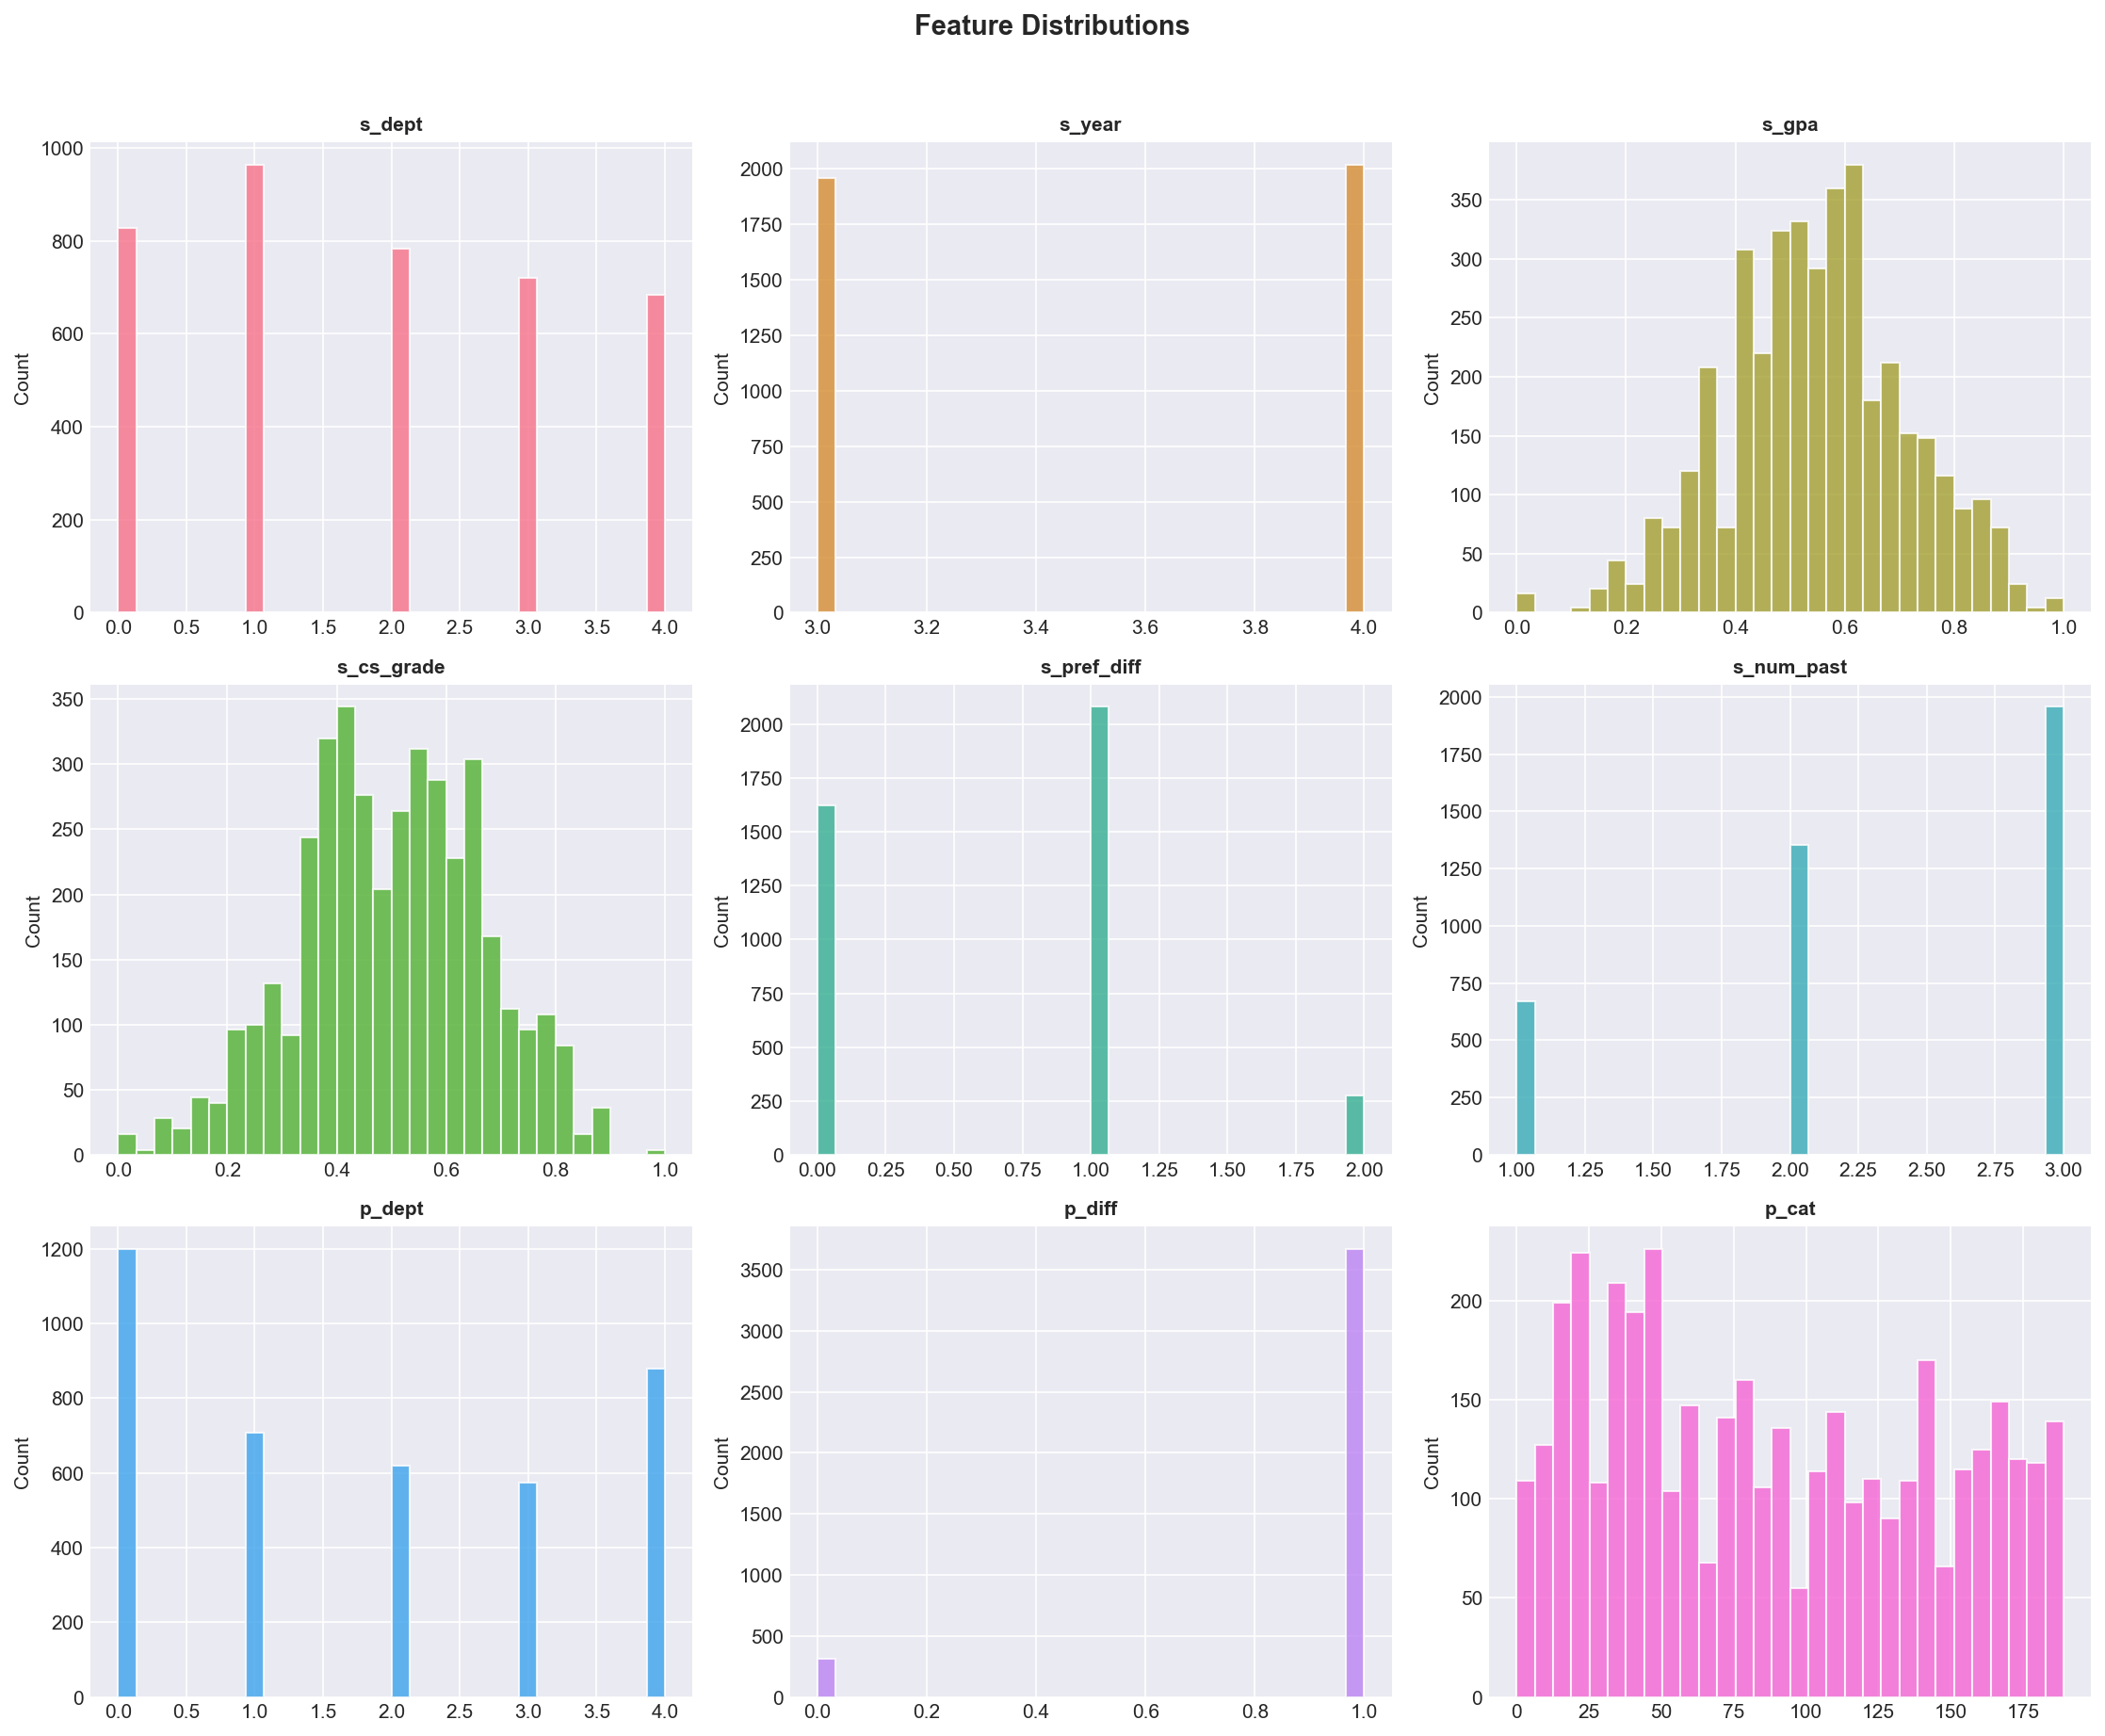

In [131]:
# Plot 13: Feature Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feat_name in enumerate(feature_names[:9]):
    axes[i].hist(X[:, i], bins=30, color=sns.color_palette("husl", 9)[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{feat_name}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('13_feature_distributions.png')

  Saved: C:\kb\student project\plots2\14_feature_correlations_target.png


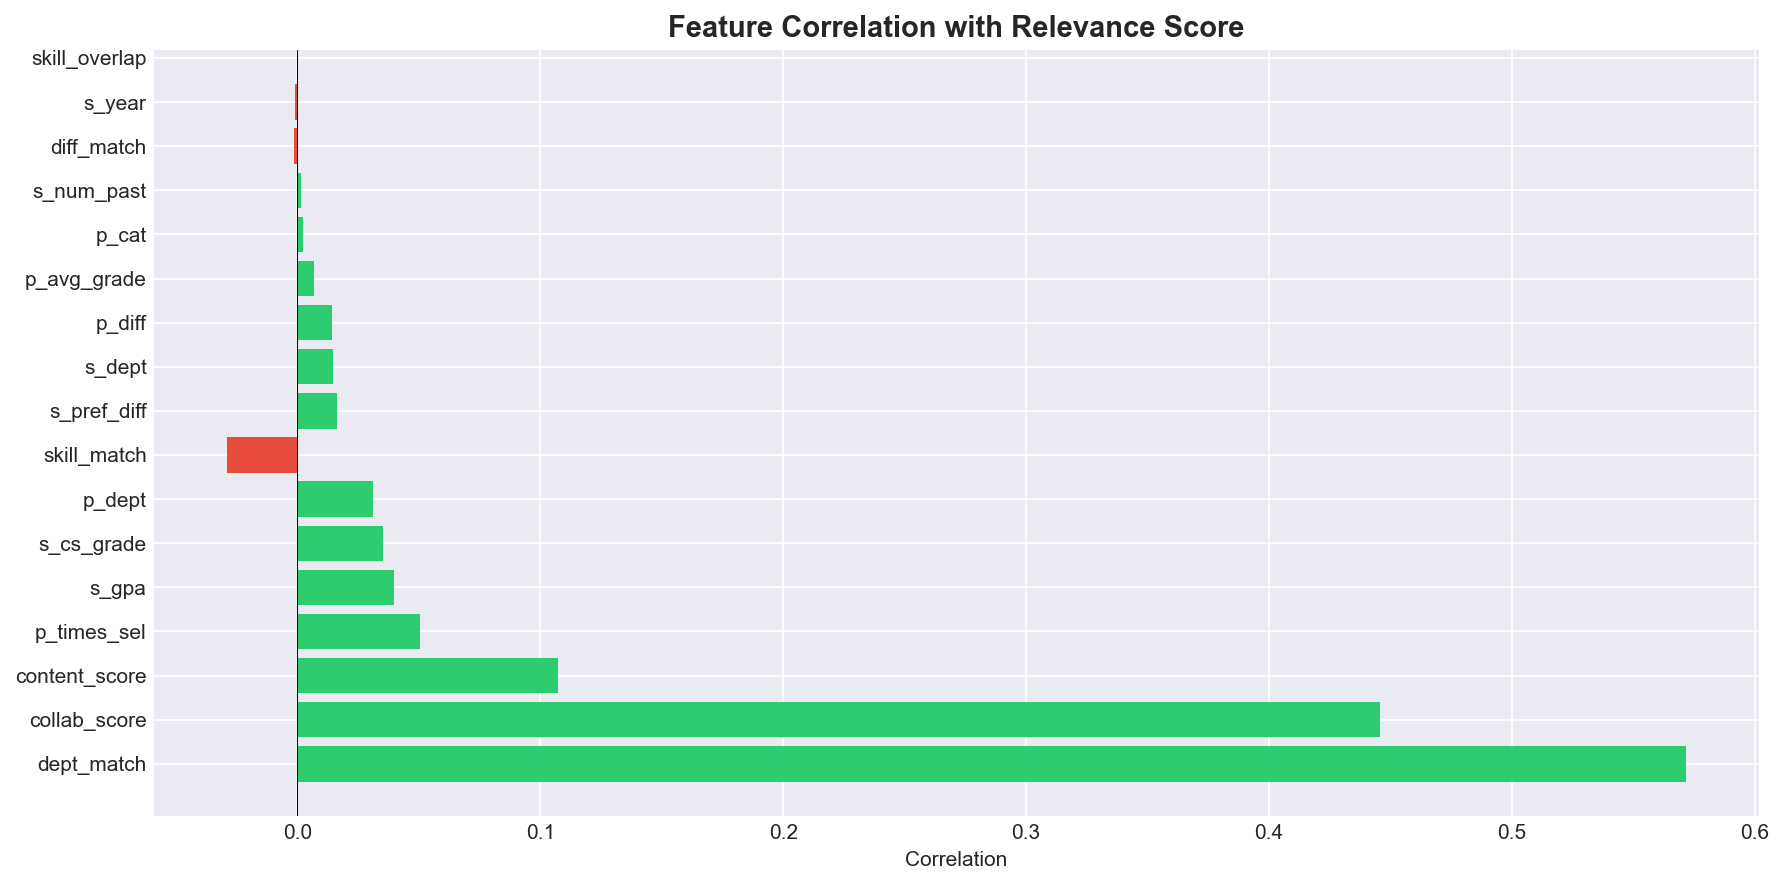

In [132]:
# Plot 14: Feature Correlations with Target
fig, ax = plt.subplots(figsize=(12, 6))

feature_corrs = []
for i, feat_name in enumerate(feature_names):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    feature_corrs.append((feat_name, corr))

feature_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
feat_names_sorted = [f[0] for f in feature_corrs]
corr_values = [f[1] for f in feature_corrs]

colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in corr_values]
ax.barh(feat_names_sorted, corr_values, color=colors)
ax.set_title('Feature Correlation with Relevance Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
save_plot('14_feature_correlations_target.png')

## 8. XGBoost Ranker Training

In [133]:
# Split and train
# Split by students so ranking groups remain intact
student_indices = list(range(n_students))
train_students, test_students = train_test_split(student_indices, test_size=0.2, random_state=42)

def build_grouped_matrix(student_list, qid_list, X, y):
    rows_X = []
    rows_y = []
    group_sizes = []
    for sid in student_list:
        idxs = [i for i, q in enumerate(qid_list) if q == sid]
        if not idxs:
            continue
        group_sizes.append(len(idxs))
        rows_X.extend(X[idxs])
        rows_y.extend(y[idxs])
    if len(rows_X) == 0:
        return np.empty((0, X.shape[1])), np.empty((0,)), []
    return np.array(rows_X), np.array(rows_y), group_sizes

X_train, y_train, train_group = build_grouped_matrix(train_students, qid_list, X, y)
X_test, y_test, test_group = build_grouped_matrix(test_students, qid_list, X, y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_names)
dtrain.set_group(train_group)
dtest.set_group(test_group)

params = {
    'objective': 'rank:pairwise',
    'eval_metric': 'ndcg',
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'seed': 42
}

evals_result = {}
model = xgb.train(params, dtrain, num_boost_round=200,
                  evals=[(dtrain, 'train'), (dtest, 'test')],
                  evals_result=evals_result, early_stopping_rounds=20, verbose_eval=50)

Train shape: (3160, 17), Test shape: (820, 17)
[0]	train-ndcg:0.93723	test-ndcg:0.92467
[20]	train-ndcg:0.98622	test-ndcg:0.88394


  Saved: C:\kb\student project\plots2\15_xgboost_training.png


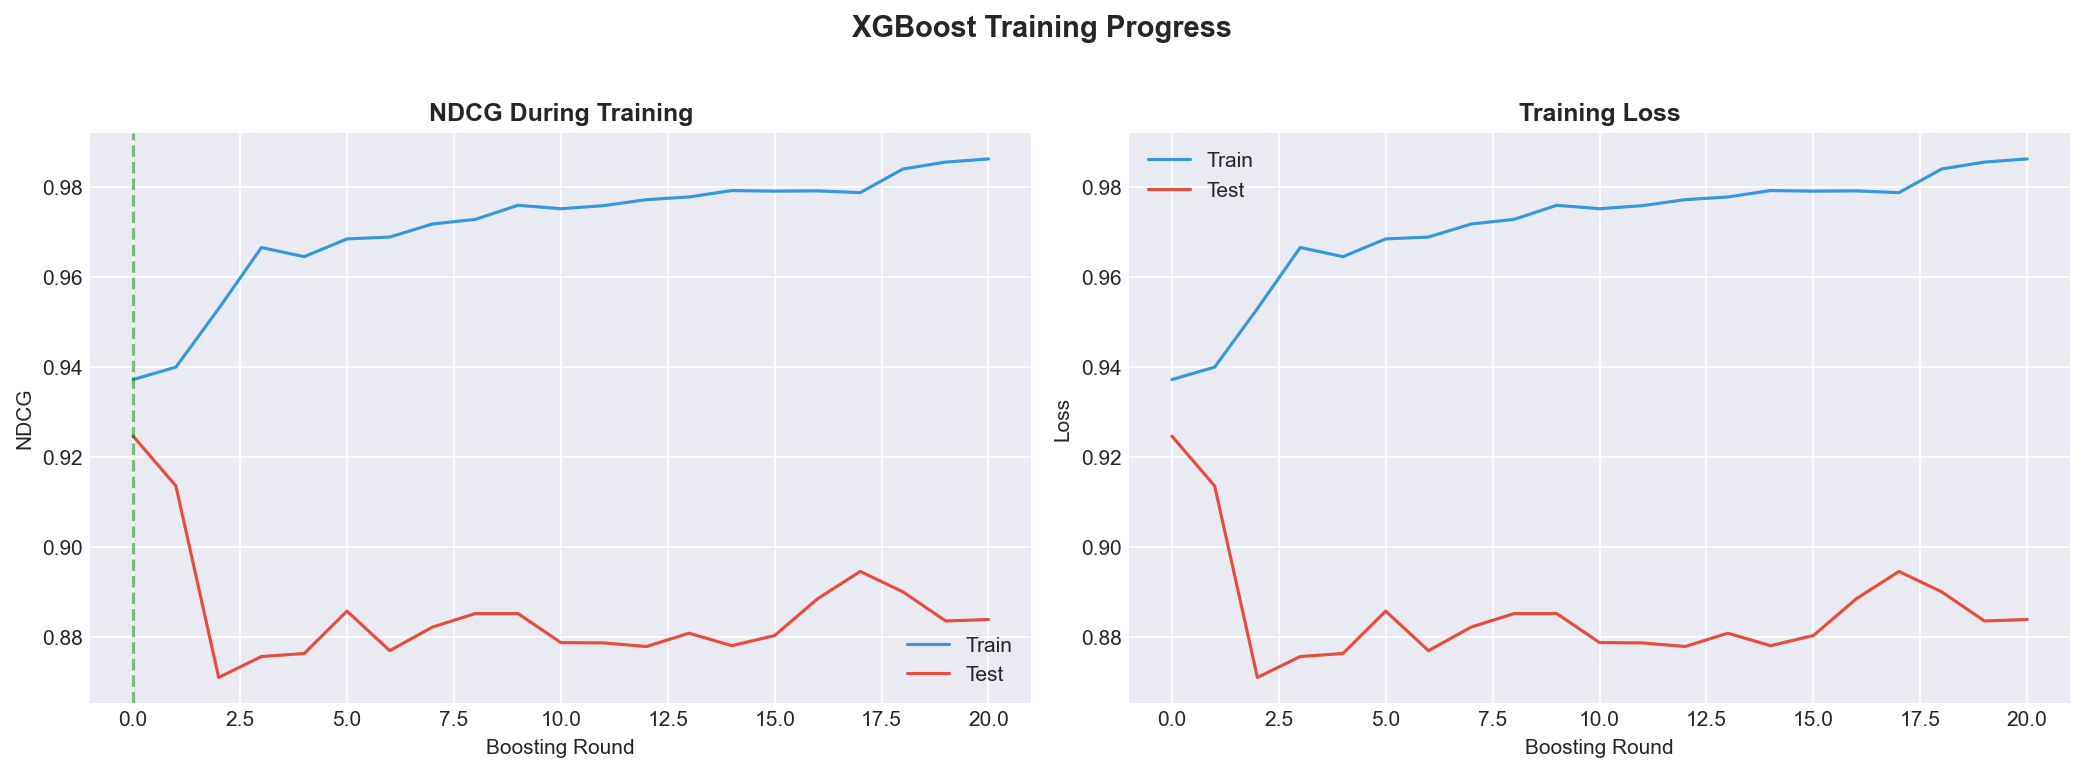

In [134]:
# Plot 15: Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(evals_result['train']['ndcg'], label='Train', color='#3498db')
axes[0].plot(evals_result['test']['ndcg'], label='Test', color='#e74c3c')
axes[0].set_title('NDCG During Training', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('NDCG')
axes[0].legend()
axes[0].axvline(x=model.best_iteration, color='green', linestyle='--', alpha=0.5)

axes[1].plot(evals_result['train'].get('ndcg', []), label='Train', color='#3498db')
axes[1].plot(evals_result['test'].get('ndcg', []), label='Test', color='#e74c3c')
axes[1].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('XGBoost Training Progress', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('15_xgboost_training.png')

  Saved: C:\kb\student project\plots2\16_feature_importance.png


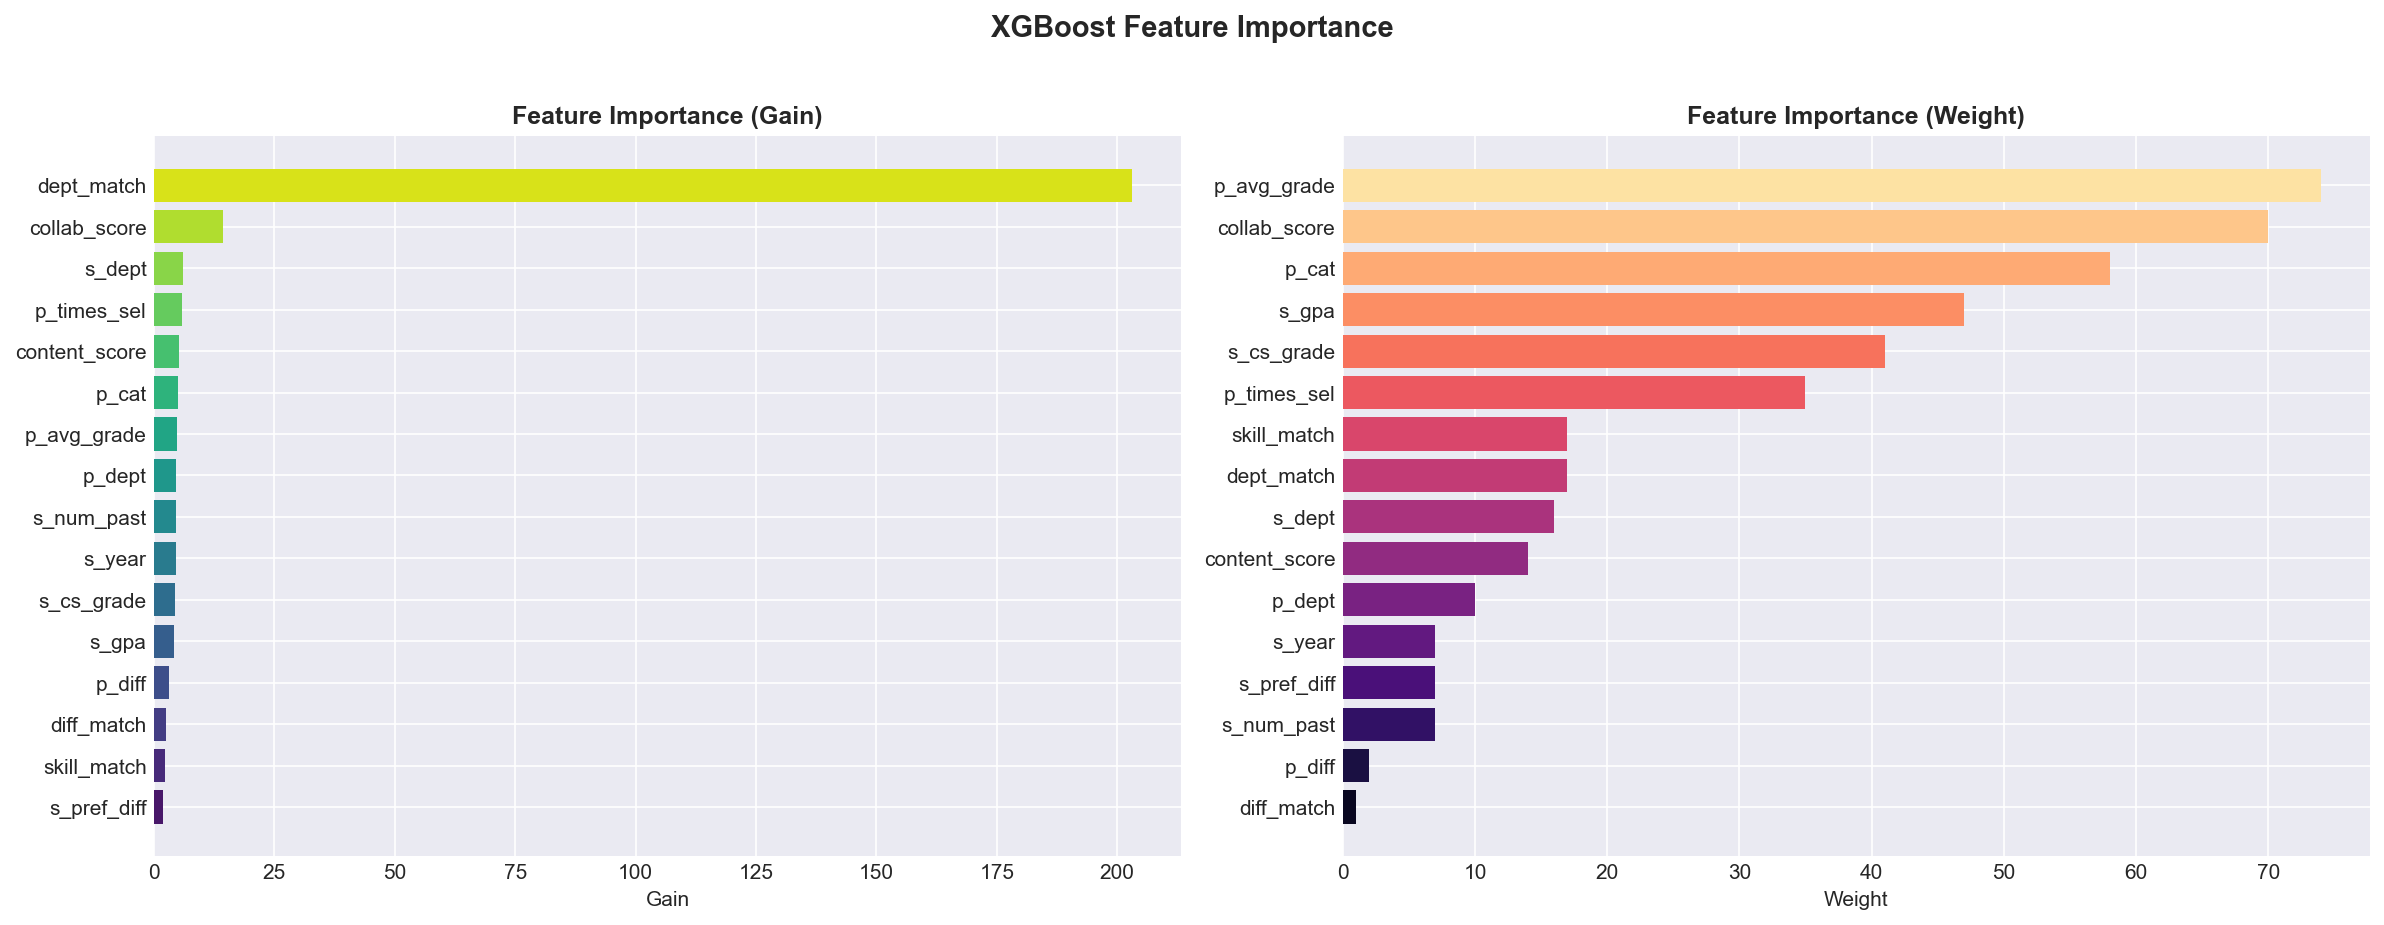

In [135]:
# Plot 16: Feature Importance
importance = model.get_score(importance_type='gain')
importance_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_names = [f[0] for f in importance_sorted]
gain_values = [f[1] for f in importance_sorted]
colors = sns.color_palette("viridis", len(feat_names))
axes[0].barh(feat_names[::-1], gain_values[::-1], color=colors)
axes[0].set_title('Feature Importance (Gain)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gain')

importance_weight = model.get_score(importance_type='weight')
importance_weight_sorted = sorted(importance_weight.items(), key=lambda x: x[1], reverse=True)
feat_names_w = [f[0] for f in importance_weight_sorted]
weight_values = [f[1] for f in importance_weight_sorted]
axes[1].barh(feat_names_w[::-1], weight_values[::-1], color=sns.color_palette("magma", len(feat_names_w)))
axes[1].set_title('Feature Importance (Weight)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weight')

plt.suptitle('XGBoost Feature Importance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('16_feature_importance.png')

## 9. Hybrid Model

In [136]:
class HybridRecommender:
    def __init__(self, xgb_model, content_weight=0.3, collab_weight=0.3, ranker_weight=0.4):
        self.model = xgb_model
        self.content_weight = content_weight
        self.collab_weight = collab_weight
        self.ranker_weight = ranker_weight

    def recommend(self, student_idx, top_n=5):
        c_scores = content_scores_all[student_idx]
        cf_scores = collab_scores_all[student_idx]

        features_array = np.column_stack([
            np.full(n_projects, student_features_df[student_idx, 0]),
            np.full(n_projects, student_features_df[student_idx, 1]),
            np.full(n_projects, student_features_df[student_idx, 2]),
            np.full(n_projects, student_features_df[student_idx, 3]),
            np.full(n_projects, student_features_df[student_idx, 4]),
            np.full(n_projects, student_features_df[student_idx, 5]),
            project_features_df[:, 0],
            project_features_df[:, 1],
            project_features_df[:, 2],
            project_features_df[:, 3],
            project_features_df[:, 4],
            skill_match_matrix[student_idx],
            dept_match_matrix[student_idx],
            diff_match_matrix[student_idx],
            c_scores,
            cf_scores,
            np.zeros(n_projects)
        ])

        dmatrix = xgb.DMatrix(features_array, feature_names=feature_names)
        ranker_scores = self.model.predict(dmatrix)
        ranker_scores = (ranker_scores - ranker_scores.min()) / (ranker_scores.max() - ranker_scores.min() + 1e-8)

        hybrid_scores = (self.content_weight * c_scores +
                        self.collab_weight * cf_scores +
                        self.ranker_weight * ranker_scores)

        top_indices = np.argsort(hybrid_scores)[-top_n:][::-1]
        return [(idx, hybrid_scores[idx], c_scores[idx], cf_scores[idx], ranker_scores[idx])
                for idx in top_indices]

recommender = HybridRecommender(model)

# Test
test_idx = 0
print(f"Student {test_idx}: {students.iloc[test_idx]['department']}, GPA: {students.iloc[test_idx]['gpa']}")
print(f"Interests: {students.iloc[test_idx]['interests']}")

recs = recommender.recommend(test_idx, top_n=5)
print(f"\nTop 5 Recommendations:")
for i, (proj_idx, score, c, cf, r) in enumerate(recs):
    proj = projects.iloc[proj_idx]
    print(f"  {i+1}. {proj['title'][:70]}...")
    print(f"     Category: {proj['category']} | Difficulty: {proj['difficulty']}")
    print(f"     Hybrid: {score:.4f} (C: {c:.4f}, CF: {cf:.4f}, R: {r:.4f})")

Student 0: Computer Science, GPA: 3.42
Interests: deep learning, machine learning

Top 5 Recommendations:
  1. Neural Network Architecture for Multi-layer Classification Using Deep ...
     Category: Classification | Difficulty: Medium
     Hybrid: 0.7433 (C: 0.4426, CF: 0.7018, R: 1.0000)
  2. TinyML Framework for Embedded Machine Learning...
     Category: Edge | Difficulty: Medium
     Hybrid: 0.6641 (C: 0.7360, CF: 0.4240, R: 0.7902)
  3. Stacked Denoising Autoencoders for Representation Learning in Deep Net...
     Category: Generative | Difficulty: Medium
     Hybrid: 0.6441 (C: 0.6667, CF: 0.4178, R: 0.7968)
  4. Meta-Reinforcement Learning Framework for Fast Learning...
     Category: Neural | Difficulty: Medium
     Hybrid: 0.6353 (C: 0.6872, CF: 0.4178, R: 0.7594)
  5. Federated Learning Framework for Privacy-Preserving Machine Learning...
     Category: AI | Difficulty: Medium
     Hybrid: 0.6317 (C: 0.6983, CF: 0.4178, R: 0.7422)


  Saved: C:\kb\student project\plots2\17_recommendation_breakdown.png


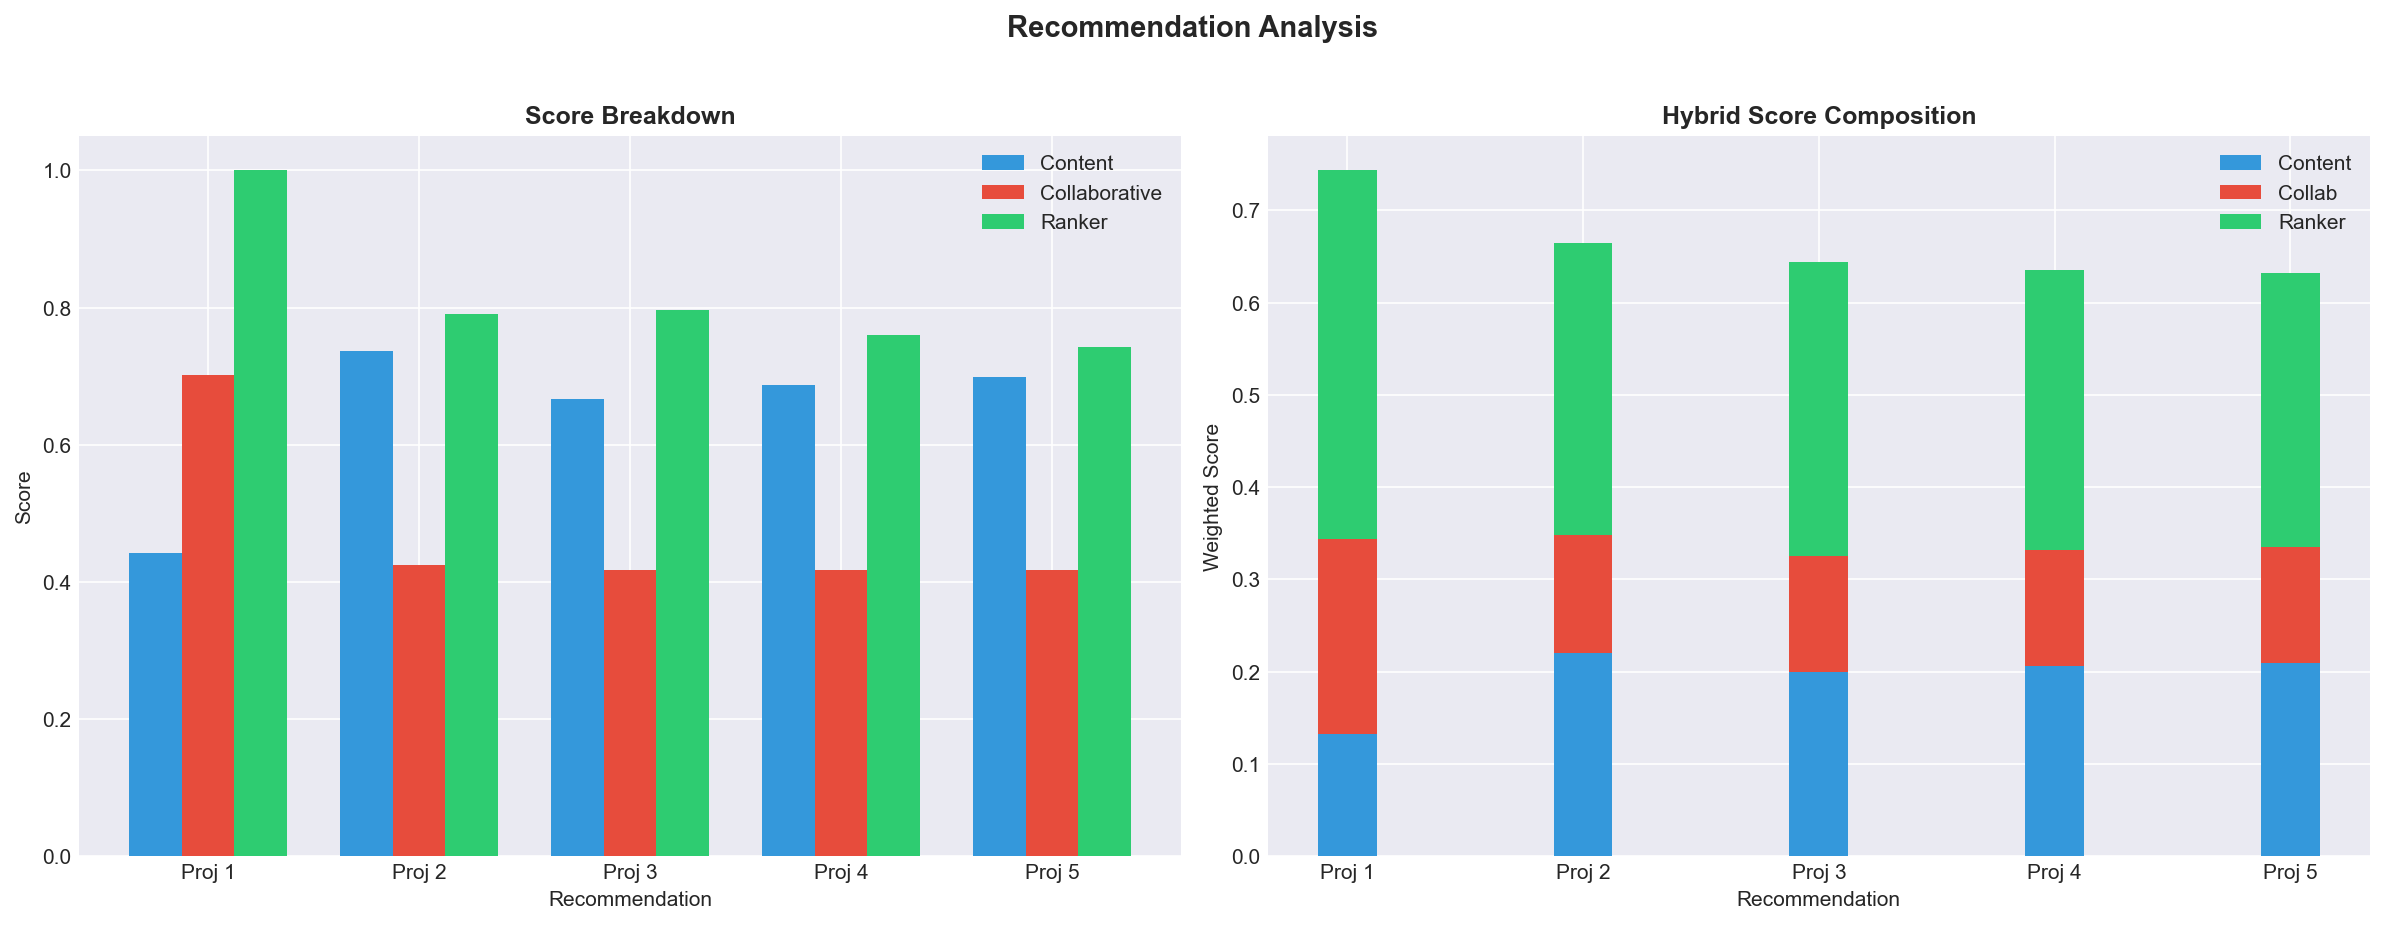

In [137]:
# Plot 17: Recommendation Breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rec_titles = [f"Proj {i+1}" for i in range(5)]
content_vals = [r[2] for r in recs]
collab_vals = [r[3] for r in recs]
ranker_vals = [r[4] for r in recs]

x = np.arange(5)
width = 0.25

axes[0].bar(x - width, content_vals, width, label='Content', color='#3498db')
axes[0].bar(x, collab_vals, width, label='Collaborative', color='#e74c3c')
axes[0].bar(x + width, ranker_vals, width, label='Ranker', color='#2ecc71')
axes[0].set_xlabel('Recommendation')
axes[0].set_ylabel('Score')
axes[0].set_title('Score Breakdown', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rec_titles)
axes[0].legend()

content_contrib = [c * recommender.content_weight for c in content_vals]
collab_contrib = [cf * recommender.collab_weight for cf in collab_vals]
ranker_contrib = [r * recommender.ranker_weight for r in ranker_vals]

axes[1].bar(x, content_contrib, width, label='Content', color='#3498db')
axes[1].bar(x, collab_contrib, width, bottom=content_contrib, label='Collab', color='#e74c3c')
axes[1].bar(x, ranker_contrib, width,
            bottom=[a+b for a, b in zip(content_contrib, collab_contrib)],
            label='Ranker', color='#2ecc71')
axes[1].set_xlabel('Recommendation')
axes[1].set_ylabel('Weighted Score')
axes[1].set_title('Hybrid Score Composition', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(rec_titles)
axes[1].legend()

plt.suptitle('Recommendation Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('17_recommendation_breakdown.png')

## 10. Evaluation

In [138]:
def evaluate_model(recommender, test_students, k=5):
    hits = 0
    total = 0
    reciprocal_ranks = []

    for student_idx in test_students[:50]:
        student_id = students.iloc[student_idx]['student_id']
        actual_projects = history[history['student_id'] == student_id]['project_id'].tolist()
        actual_project_ids = set(actual_projects)
        if not actual_project_ids:
            continue
        recs = recommender.recommend(student_idx, top_n=k)
        rec_project_ids = [projects.iloc[r[0]]['project_id'] for r in recs]
        for rank, proj_id in enumerate(rec_project_ids):
            if proj_id in actual_project_ids:
                hits += 1
                reciprocal_ranks.append(1.0 / (rank + 1))
                break
        total += 1

    return {
        'Precision@K': hits / total if total > 0 else 0,
        'Hit Rate@K': hits / total if total > 0 else 0,
        'MRR': np.mean(reciprocal_ranks) if reciprocal_ranks else 0
    }

metrics = evaluate_model(recommender, list(range(min(100, n_students))), k=5)
print("\nEvaluation Metrics:")
for metric, value in metrics.items():
    print(f"  {metric}: {value:.4f}")


Evaluation Metrics:
  Precision@K: 0.4800
  Hit Rate@K: 0.4800
  MRR: 0.7604


  Saved: C:\kb\student project\plots2\18_evaluation_summary.png


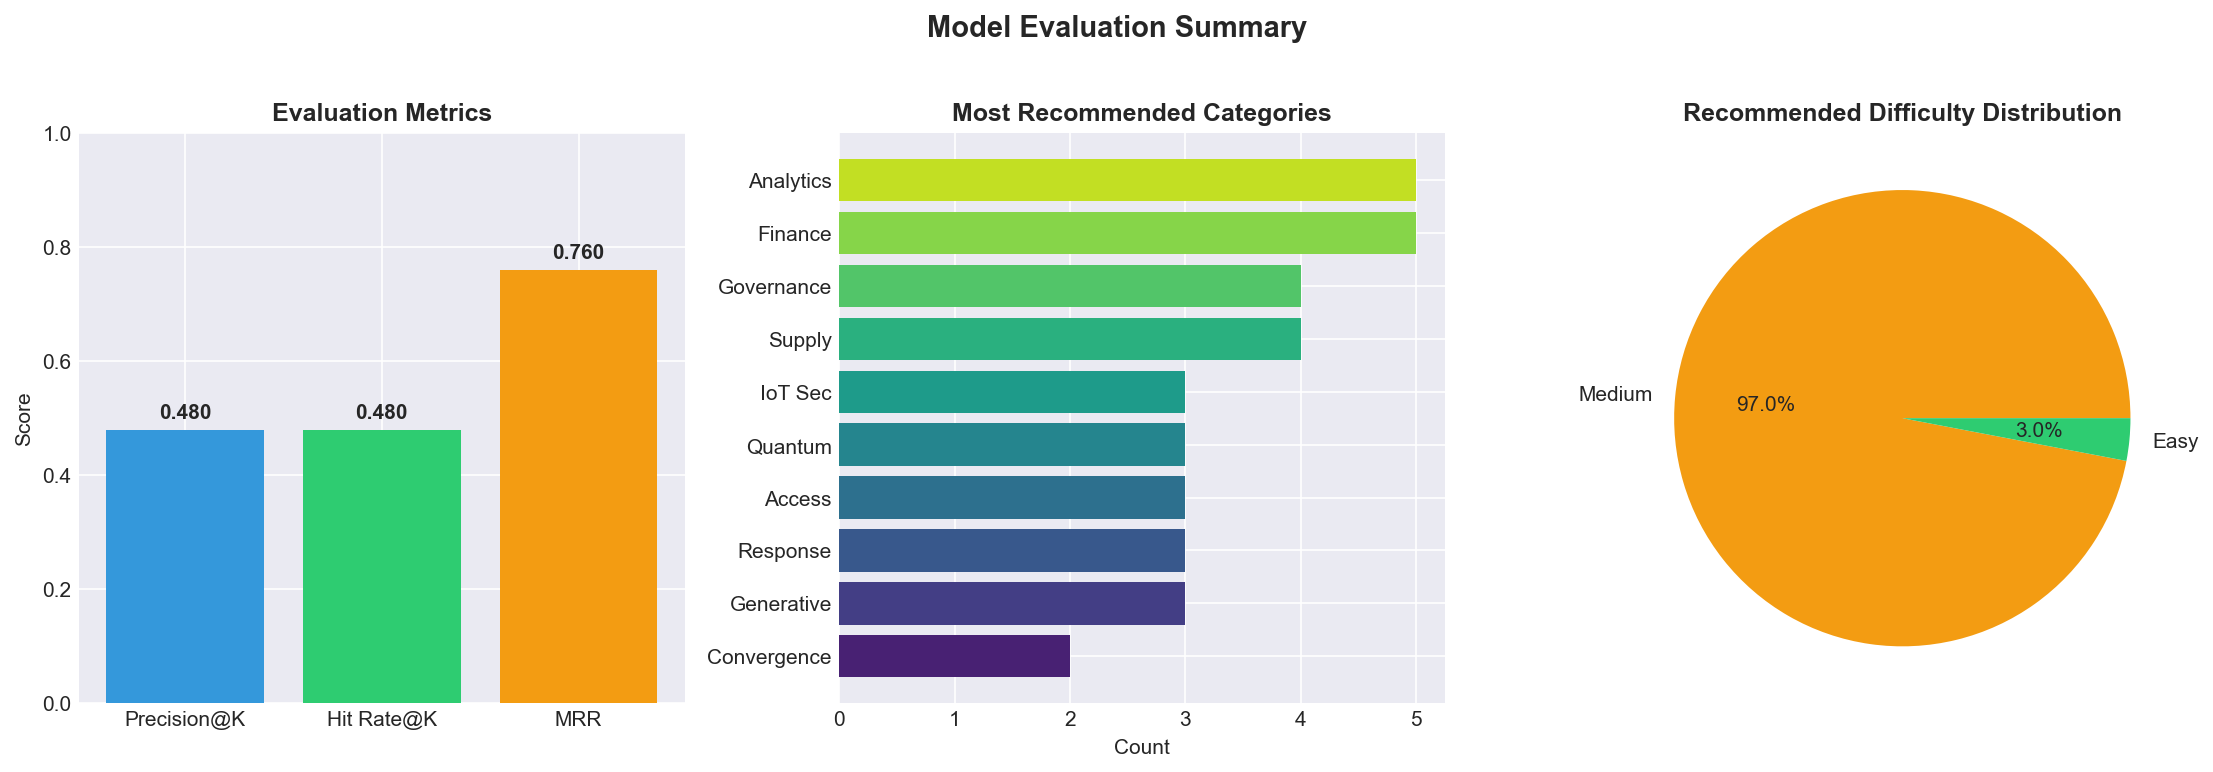

In [139]:
# Plot 18: Evaluation Summary
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metric_names = list(metrics.keys())
metric_values = list(metrics.values())
colors = ['#3498db', '#2ecc71', '#f39c12']
axes[0].bar(metric_names, metric_values, color=colors)
axes[0].set_title('Evaluation Metrics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(metric_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Most recommended categories
top_cats = []
for i in range(min(20, n_students)):
    recs = recommender.recommend(i, top_n=5)
    for r in recs:
        top_cats.append(projects.iloc[r[0]]['category'])

cat_series = pd.Series(top_cats).value_counts().head(10)
axes[1].barh(cat_series.index[::-1], cat_series.values[::-1], color=sns.color_palette("viridis", 10))
axes[1].set_title('Most Recommended Categories', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

# Difficulty distribution
diff_dist = []
for i in range(min(20, n_students)):
    recs = recommender.recommend(i, top_n=5)
    for r in recs:
        diff_dist.append(projects.iloc[r[0]]['difficulty'])

diff_series = pd.Series(diff_dist).value_counts()
colors_diff = {'Easy': '#2ecc71', 'Medium': '#f39c12', 'Hard': '#e74c3c'}
axes[2].pie(diff_series.values, labels=diff_series.index, autopct='%1.1f%%',
            colors=[colors_diff.get(x, '#95a5a6') for x in diff_series.index])
axes[2].set_title('Recommended Difficulty Distribution', fontsize=12, fontweight='bold')

plt.suptitle('Model Evaluation Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot('18_evaluation_summary.png')

## 11. Save Model Artifacts

In [140]:
import pickle

model.save_model(r"C:\kb\student project\model2\xgboost_ranker.json")

with open(r"C:\kb\student project\model2\encoders.pkl", 'wb') as f:
    pickle.dump({
        'dept_encoder': dept_encoder,
        'cat_encoder': cat_encoder,
        'interest_vectorizer': interest_vectorizer,
        'project_vectorizer': project_vectorizer,
        'scaler': scaler,
        'feature_names': feature_names
    }, f)

np.save(r"C:\kb\student project\model2\student_factors.npy", student_factors)
np.save(r"C:\kb\student project\model2\project_factors.npy", project_factors)
np.save(r"C:\kb\student project\model2\content_scores_all.npy", content_scores_all)
np.save(r"C:\kb\student project\model2\collab_scores_all.npy", collab_scores_all)
np.save(r"C:\kb\student project\model2\skill_match_matrix.npy", skill_match_matrix)
np.save(r"C:\kb\student project\model2\dept_match_matrix.npy", dept_match_matrix)
np.save(r"C:\kb\student project\model2\diff_match_matrix.npy", diff_match_matrix)

print("Model artifacts saved!")
print(f"  Model: C:\\kb\\student project\\model\\xgboost_ranker.json")
print(f"  Plots: C:\\kb\\student project\\plots\\ (18 files)")

Model artifacts saved!
  Model: C:\kb\student project\model2\xgboost_ranker.json
  Plots: C:\kb\student project\plots2\ (18 files)


## Summary

### Visualizations Generated (18 plots)

| # | Filename | Description |
|---|----------|-------------|
| 1 | 01_dataset_overview.png | Students/Projects/Difficulty distribution |
| 2 | 02_student_demographics.png | GPA, Year level, Department analysis |
| 3 | 03_project_categories.png | Top categories, Dept x Difficulty |
| 4 | 04_wordclouds.png | Project titles and Student interests |
| 5 | 05_history_analysis.png | Grades, Completion, Ratings, Semesters |
| 6 | 06_skills_distribution.png | Programming languages and Tools |
| 7 | 07_feature_correlations.png | Student feature correlation heatmap |
| 8 | 08_content_based_scores.png | Content-based score distribution |
| 9 | 09_collaborative_matrix.png | Interaction matrix and sparsity |
| 10 | 10_svd_analysis.png | SVD variance and latent factors |
| 11 | 11_content_vs_collab.png | Content vs Collaborative comparison |
| 12 | 12_training_data.png | Training pair distribution |
| 13 | 13_feature_distributions.png | Feature value distributions |
| 14 | 14_feature_correlations_target.png | Feature-Target correlations |
| 15 | 15_xgboost_training.png | Training NDCG and loss curves |
| 16 | 16_feature_importance.png | XGBoost feature importance |
| 17 | 17_recommendation_breakdown.png | Score composition analysis |
| 18 | 18_evaluation_summary.png | Precision, Hit Rate, MRR |